In [1]:
import sys
import os
import numpy as np
from scipy.ndimage import gaussian_filter1d

import copy
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import balanced_accuracy_score, confusion_matrix

repo_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

from utils.glm_wrapper_functions_cluster import glm_wrapper_functions_cluster

In [2]:
def smooth_spike_trials(Y_trials, sigma=2.0):
    """
    Smooth binarized spike/deconvolved trials along time only.

    Parameters
    ----------
    Y_trials : list of np.ndarray
        Each array has shape [T, n_neurons].
    sigma : float
        Gaussian sigma in units of frames.

    Returns
    -------
    Y_smooth_trials : list of np.ndarray
        Smoothed arrays, same shape as input.
    """
    Y_smooth_trials = []
    for Y in Y_trials:
        Y_smooth = gaussian_filter1d(
            Y.astype(np.float32),
            sigma=sigma,
            axis=0,          # smooth over time
            mode="nearest"
        )
        Y_smooth_trials.append(Y_smooth)
    return Y_smooth_trials

In [3]:
# Load the data
glm_wrapper = glm_wrapper_functions_cluster()
mouse,date,model_name,server = 'HA11-1R','2023-05-05','GLM_3nmf_pre', 'V:'
data_directory = os.path.join('V:/Connie/ProcessedData',mouse,date,model_name) 
# data_directory = os.path.join('/ix/crunyan/cdb66/Data',mouse,date,model_name) #SLURM ALREADY CD's to the directory
# save_directory = os.path.join('/ix/crunyan/cdb66/Data',mouse,date,model_name,'results_updated')

num_folds = 10
fold_data = {}
for fold_number in list(range(0,num_folds)): #can change this to fit however many folds you need 

    print(f"Loading fold {fold_number + 1}/{num_folds}...")

    train_directory = data_directory + "/prepost trial cv 73 #{}".format(fold_number+1)
    test_directory = data_directory + "/prepost trial cv 73 #{}/test".format(fold_number+1)
    
    X_train_trials,Y_train_trials,X_test_trials,Y_test_trials,correct_train,correct_test,_,IDS_for_count_of_values = glm_wrapper.get_glm_predictors_data_from_each_CV_fold(
        train_directory,
        test_directory,
        fold_number,
        raw_deconvolved=0,
        ctx_value=1)

    model_name = 'GLM_3nmf_passive'
    X_train_trials_pass,Y_train_trials_pass,X_test_trials_pass,Y_test_trials_pass,_,_,_,IDS_for_count_of_values = glm_wrapper.get_glm_predictors_data_from_each_CV_fold(
        train_directory,
        test_directory,
        fold_number,
        raw_deconvolved=0,
        ctx_value=0)
    
    # smooth neural responses
    Y_test_trials = smooth_spike_trials(Y_test_trials, sigma=2)
    Y_train_trials = smooth_spike_trials(Y_train_trials, sigma=2)

    # ----------------------------------------
    # Store this fold
    # ----------------------------------------

    fold_data[fold_number] = {

        "X_train": X_train_trials,
        "Y_train": Y_train_trials,

        "X_test": X_test_trials,
        "Y_test": Y_test_trials,

        "correct_train": correct_train,
        "correct_test": correct_test
    }

    print(
        f"  train trials: {len(X_train_trials)} | "
        f"test trials: {len(X_test_trials)}"
    )
    
print(f'Make sure sizes of correct_trials train: {len(correct_train)} and Xtrain {len(X_train_trials)} match')

# ============================================================
# Check all folds
# ============================================================

for fold_number, data in fold_data.items():

    print(
        f"Fold {fold_number + 1}: "
        f"train={len(data['X_train'])}, "
        f"test={len(data['X_test'])}, "
        f"X={data['X_train'][0].shape}, "
        f"Y={data['Y_train'][0].shape}, "
        f"labels="
        f"{np.unique(data['correct_train'], return_counts=True)}"
    )


Loading fold 1/10...
129
None
  train trials: 158 | test trials: 62
Loading fold 2/10...
128
None
  train trials: 158 | test trials: 62
Loading fold 3/10...
127
None
  train trials: 158 | test trials: 62
Loading fold 4/10...
127
None
  train trials: 158 | test trials: 62
Loading fold 5/10...
128
None
  train trials: 158 | test trials: 62
Loading fold 6/10...
128
None
  train trials: 158 | test trials: 62
Loading fold 7/10...
127
None
  train trials: 158 | test trials: 62
Loading fold 8/10...
128
None
  train trials: 158 | test trials: 62
Loading fold 9/10...
127
None
  train trials: 158 | test trials: 62
Loading fold 10/10...
128
None
  train trials: 158 | test trials: 62
Make sure sizes of correct_trials train: 158 and Xtrain 158 match
Fold 1: train=158, test=62, X=(320, 184), Y=(320, 385), labels=(array([0, 1]), array([ 29, 129], dtype=int64))
Fold 2: train=158, test=62, X=(243, 184), Y=(243, 385), labels=(array([0, 1]), array([ 30, 128], dtype=int64))
Fold 3: train=158, test=62, X=(

First let's look at a single fold

Model 0: Simple RNN - Can recurrent dynamics predict trial outcome?

In [4]:

class SimpleRateRNN(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, alpha=0.2):
        super().__init__()

        self.hidden_dim = hidden_dim
        self.alpha = alpha

        # Input and recurrent weights
        self.W_in = nn.Linear(input_dim, hidden_dim, bias=True)
        self.W_rec = nn.Linear(hidden_dim, hidden_dim, bias=False)

        # Output readout (choice)
        self.W_out = nn.Linear(hidden_dim, output_dim)

    def forward_trial(self, X):
        """
        X: Tensor [T, D] for one trial
        Returns:
            logits: Tensor [output_dim]
            hidden_states: Tensor [T, hidden_dim]
        """
        T = X.shape[0]
        h = torch.zeros(self.hidden_dim, device=X.device)

        hidden_states = []

        for t in range(T):
            h = (1 - self.alpha) * h + self.alpha * torch.tanh(
                self.W_rec(h) + self.W_in(X[t])
            )
            hidden_states.append(h)

        hidden_states = torch.stack(hidden_states, dim=0)

        # Readout from final state
        logits = self.W_out(h)

        return logits, hidden_states

    


In [5]:
# Prepare data for PyTorch and convert to tensors
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

X_train_trials_torch = [
    torch.tensor(X, dtype=torch.float32, device=device)
    for X in X_train_trials
]

y_train_labels = correct_train  # assuming correct_train is a list of labels per trial
y_train = torch.tensor(
    y_train_labels, dtype=torch.long, device=device
)


In [19]:
# instantiate the model
input_dim = X_train_trials_torch[0].shape[1]
hidden_dim = 128     # start modest
output_dim = 2       # left / right

all_hidden_states = []
all_logits = []
all_labels = []

model = SimpleRateRNN(
    input_dim=input_dim,
    hidden_dim=hidden_dim,
    output_dim=output_dim,
    alpha=0.2
).to(device)


def train_m0(
    model,
    X_train,
    y_train,
    n_epochs=5,
    lr=1e-3
):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    history = []

    for epoch in range(n_epochs):

        model.train()
        total_loss = 0.0

        for k, X_trial in enumerate(X_train):

            optimizer.zero_grad()

            logits, _ = model.forward_trial(X_trial)

            loss = criterion(
                logits.unsqueeze(0),
                y_train[k].unsqueeze(0)
            )

            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        history.append(total_loss)

    return history
train_history = train_m0(
    model,
    X_train_trials_torch,
    y_train,
    n_epochs=5,
    lr=1e-3
)

In [23]:
from sklearn.metrics import balanced_accuracy_score, confusion_matrix


def evaluate_m0(model, X_test, y_test):

    model.eval()

    preds = []

    with torch.no_grad():

        for X_trial in X_test:

            logits, _ = model.forward_trial(X_trial)

            pred = torch.argmax(logits).item()

            preds.append(pred)

    y_true = y_test.detach().cpu().numpy()
    preds = np.asarray(preds)

    accuracy = np.mean(preds == y_true)

    majority_accuracy = np.max(
        np.bincount(y_true)
    ) / len(y_true)

    balanced_accuracy = balanced_accuracy_score(
        y_true,
        preds
    )

    cm = confusion_matrix(
        y_true,
        preds,
        labels=[0, 1]
    )

    return {
        "accuracy": accuracy,
        "majority_accuracy": majority_accuracy,
        "balanced_accuracy": balanced_accuracy,

        "TN": cm[0, 0],
        "FP": cm[0, 1],
        "FN": cm[1, 0],
        "TP": cm[1, 1]
    }

eval_results = evaluate_m0(
    model,
    X_test_trials_torch,
    y_test
)
eval_results

{'accuracy': 1.0,
 'majority_accuracy': 0.8225806451612904,
 'balanced_accuracy': 1.0,
 'TN': 11,
 'FP': 0,
 'FN': 0,
 'TP': 51}

In [26]:
model.eval()
test_preds = []
test_labels = []

# ============================================================
# Convert trial data to PyTorch tensors
# ============================================================

X_train_trials_torch = [
    torch.tensor(x, dtype=torch.float32, device=device)
    for x in X_train_trials
]

X_test_trials_torch = [
    torch.tensor(x, dtype=torch.float32, device=device)
    for x in X_test_trials
]

Y_train_trials_torch = [
    torch.tensor(y, dtype=torch.float32, device=device)
    for y in Y_train_trials
]

Y_test_trials_torch = [
    torch.tensor(y, dtype=torch.float32, device=device)
    for y in Y_test_trials
]


y_train = torch.tensor(
    correct_train,
    dtype=torch.long,
    device=device
) if not torch.is_tensor(y_train) else y_train.to(
    device=device,
    dtype=torch.long
)

y_test_labels = correct_test  # assuming correct_train is a list of labels per trial
y_test = torch.tensor(
    y_test_labels, dtype=torch.long, device=device
)

with torch.no_grad():
    for k, X_trial in enumerate(X_test_trials_torch):
        logits, _ = model.forward_trial(X_trial)
        pred = torch.argmax(logits).item()
        test_preds.append(pred)
        test_labels.append(y_test[k])

test_acc = np.mean(np.array(test_preds) == np.array(test_labels))
print("Test accuracy:", test_acc)


Test accuracy: 1.0


In [24]:
def separation_over_time(trials, labels):
    min_len = min(h.shape[0] for h in trials)
    dists = []

    for t in range(min_len):
        mean_c = np.mean([h[t] for h, y in zip(trials, labels) if y == 1], axis=0)
        mean_i = np.mean([h[t] for h, y in zip(trials, labels) if y == 0], axis=0)
        dists.append(np.linalg.norm(mean_c - mean_i))

    return np.array(dists)

sep = separation_over_time(all_hidden_states, labels)

plt.figure()
plt.plot(sep)
plt.xlabel('Time')
plt.ylabel('State separation')
plt.title('Correct vs incorrect separation over time')
plt.show()


ValueError: min() arg is an empty sequence

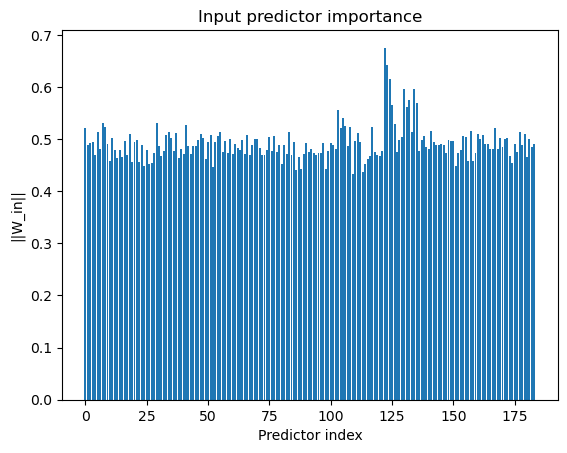

In [12]:
W_in = model.W_in.weight.detach().cpu().numpy()
input_strength = np.linalg.norm(W_in, axis=0)

plt.figure()
plt.bar(np.arange(len(input_strength)), input_strength)
plt.xlabel('Predictor index')
plt.ylabel('||W_in||')
plt.title('Input predictor importance')
plt.show()


Passive-context test accuracy: 0.8387096774193549


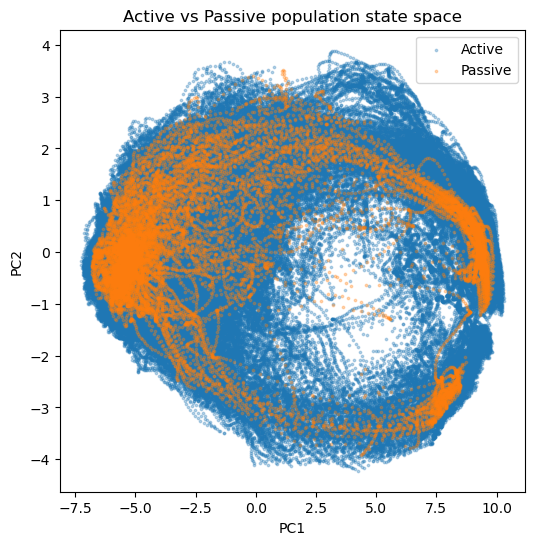

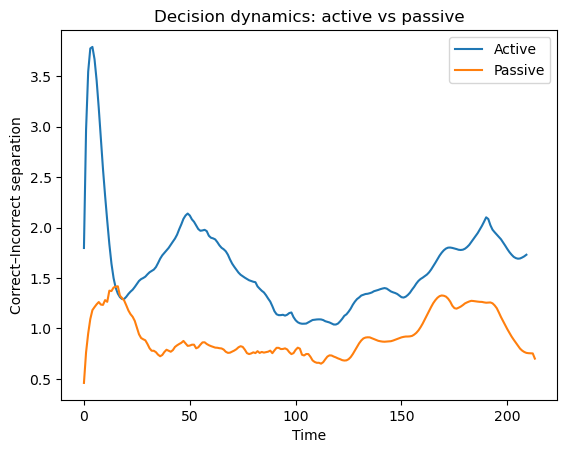

In [13]:
X_test_passive_torch = [
    torch.tensor(X, dtype=torch.float32, device=device)
    for X in X_test_trials_pass
]


# run the passive test loop (no gradients)
model.eval()

passive_logits = []
passive_hidden_states = []

with torch.no_grad():
    for X_trial in X_test_passive_torch:
        logits, hidden_states = model.forward_trial(X_trial)
        passive_logits.append(logits.cpu())
        passive_hidden_states.append(hidden_states.cpu())

#sanity tests
passive_preds = [torch.argmax(l).item() for l in passive_logits]
passive_acc = np.mean(np.array(passive_preds) == np.array(test_labels))

print("Passive-context test accuracy:", passive_acc)

H_active = np.concatenate([h.numpy() for h in all_hidden_states], axis=0)
H_passive = np.concatenate([h.numpy() for h in passive_hidden_states], axis=0)

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=3)
H_active_pca = pca.fit_transform(H_active)
H_passive_pca = pca.transform(H_passive)

plt.figure(figsize=(6,6))
plt.scatter(H_active_pca[:,0], H_active_pca[:,1],
            s=3, alpha=0.3, label='Active')
plt.scatter(H_passive_pca[:,0], H_passive_pca[:,1],
            s=3, alpha=0.3, label='Passive')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.title('Active vs Passive population state space')
plt.show()

#Time-resolved separation (active vs passive)
sep_active = separation_over_time(all_hidden_states, labels)
sep_passive = separation_over_time(passive_hidden_states, labels)

plt.figure()
plt.plot(sep_active, label='Active')
plt.plot(sep_passive, label='Passive')
plt.xlabel('Time')
plt.ylabel('Correct–Incorrect separation')
plt.legend()
plt.title('Decision dynamics: active vs passive')
plt.show()






Update RNN Model to predict neuronal activity

In [40]:
# ----------------------------
# Model architecture
# ----------------------------

input_dim = X_train_trials_torch[0].shape[1]
hidden_dim = 128
output_dim = 2
n_neurons =Y_train_trials[0].shape[1]

alpha = 0.2


# ----------------------------
# Training settings
# ----------------------------

beta = 20
lambda_neural = 5.0

learning_rate = 1e-3
n_epochs = 50
grad_clip = 1.0

In [33]:
# Neural Rate RNN
#
# M1: dale=False  -> unconstrained recurrent connectivity
# M2: dale=True   -> Dale-constrained recurrent connectivity
# ============================================================

class NeuralRateRNN(nn.Module):

    def __init__(
        self,
        input_dim,
        hidden_dim,
        output_dim,
        n_neurons,
        alpha=0.2,
        dale=False,
        dale_sign=None,
        dale_orientation="column"
    ):
        super().__init__()

        self.hidden_dim = hidden_dim
        self.alpha = alpha
        self.dale = dale
        self.dale_orientation = dale_orientation

        self.W_in = nn.Linear(
            input_dim,
            hidden_dim,
            bias=True
        )

        # ----------------------------------------
        # Recurrent connectivity
        # ----------------------------------------

        if dale:
            # Choose Theta so that after softplus,
            # effective recurrent magnitudes begin near 0.04,
            # comparable to the unconstrained model.
            
            target_magnitude = 0.04
            
            theta_center = np.log(
                np.exp(target_magnitude) - 1
            )

            self.Theta_rec = nn.Parameter(
                theta_center
                + torch.randn(hidden_dim, hidden_dim) * 0.05
            )

        else:
            # Unconstrained M1
            self.Theta_rec = nn.Parameter(
                torch.randn(hidden_dim, hidden_dim) * 0.05
            )

                # self.Theta_rec = nn.Parameter(
                #     torch.randn(hidden_dim, hidden_dim) * 0.05
                # )

        if dale:

            self.register_buffer(
                "dale_sign",
                dale_sign.view(1, hidden_dim)  # columns = presynaptic/source units
            )

        self.W_out = nn.Linear(
            hidden_dim,
            output_dim
        )

        self.C = nn.Linear(
            hidden_dim,
            n_neurons,
            bias=True
        )


    def recurrent_weights(self):

        if self.dale:
            W_pos = F.softplus(self.Theta_rec)
            return self.dale_sign * W_pos

        return self.Theta_rec


    def forward_trial(self, X):

        T = X.shape[0]

        h = torch.zeros(
            self.hidden_dim,
            device=X.device
        )

        hs = []
        yhats = []

        Wrec = self.recurrent_weights()

        for t in range(T):

            pre = (
                Wrec @ h
                + self.W_in(X[t])
            )

            h = (
                (1 - self.alpha) * h
                + self.alpha * torch.tanh(pre)
            )

            hs.append(h)

            yhat_t = F.softplus(
                self.C(h)
            )

            yhats.append(yhat_t)

        hs = torch.stack(
            hs,
            dim=0
        )

        yhat = torch.stack(
            yhats,
            dim=0
        )

        logits = self.W_out(h)

        return logits, hs, yhat

# ============================================================
# Latent E/I composition for Dale-constrained model
# ============================================================

n_exc = int(0.70 * hidden_dim)
n_pv = int(0.20 * hidden_dim)
n_som = hidden_dim - n_exc - n_pv

dale_sign = torch.cat([
    torch.ones(n_exc),
    -torch.ones(n_pv),
    -torch.ones(n_som)
]).to(device)

print(f"Excitatory latent units: {n_exc}")
print(f"PV-like inhibitory units: {n_pv}")
print(f"SOM-like inhibitory units: {n_som}")
print(f"Total: {len(dale_sign)}")


Excitatory latent units: 89
PV-like inhibitory units: 25
SOM-like inhibitory units: 14
Total: 128


In [34]:
# Create model function
def create_model(
    dale=False,
    seed=0,
    dale_orientation="column"
):

    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    model = NeuralRateRNN(
        input_dim=input_dim,
        hidden_dim=hidden_dim,
        output_dim=output_dim,
        n_neurons=n_neurons,
        alpha=alpha,
        dale=dale,
        dale_sign=dale_sign if dale else None,
        dale_orientation=dale_orientation
    ).to(device)

    return model

In [35]:
# Shared training function for M1 / M2
# ============================================================

def train_neural_rnn(
    model,
    X_train,
    Y_train,
    y_train,
    beta=20,
    lambda_neural=5.0,
    lr=1e-3,
    n_epochs=50,
    grad_clip=1.0,
    verbose_every=10
):
    """
    Train a rate RNN to jointly predict:
        1. trial-level behavioral outcome
        2. time-resolved neural activity

    Parameters
    ----------
    model : nn.Module
        M1 or M2.

    X_train : list of torch.Tensor
        Predictor arrays, one [T x input_dim] tensor per trial.

    Y_train : list of torch.Tensor
        Neural targets, one [T x n_neurons] tensor per trial.

    y_train : torch.Tensor
        Trial-level behavioral labels.

    beta : float
        Strength of activity-dependent weighting in neural MSE.

    lambda_neural : float
        Weight of neural loss relative to behavioral loss.
    """

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion_choice = nn.CrossEntropyLoss()

    history = {
        "total_loss": [],
        "choice_loss": [],
        "neural_loss": []
    }

    for epoch in range(n_epochs):

        model.train()

        total_loss = 0.0
        total_choice_loss = 0.0
        total_neural_loss = 0.0

        for k, (X_trial, Y_trial) in enumerate(zip(X_train, Y_train)):

            optimizer.zero_grad()

            logits, hidden_states, yhat = model.forward_trial(X_trial)

            # -------------------------
            # Behavioral loss
            # -------------------------
            loss_choice = criterion_choice(
                logits.unsqueeze(0),
                y_train[k].unsqueeze(0)
            )

            # -------------------------
            # Neural loss
            # -------------------------
            weights = 1.0 + beta * Y_trial

            squared_error = (yhat - Y_trial) ** 2

            loss_neural = (
                (weights * squared_error).sum()
                / weights.sum()
            )

            # -------------------------
            # Combined objective
            # -------------------------
            loss = (
                loss_choice
                + lambda_neural * loss_neural
            )

            loss.backward()

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                grad_clip
            )

            optimizer.step()

            total_loss += loss.item()
            total_choice_loss += loss_choice.item()
            total_neural_loss += loss_neural.item()

        history["total_loss"].append(total_loss)
        history["choice_loss"].append(total_choice_loss)
        history["neural_loss"].append(total_neural_loss)

        if (
            epoch == 0
            or (epoch + 1) % verbose_every == 0
            or epoch == n_epochs - 1
        ):
            print(
                f"Epoch {epoch + 1:02d}/{n_epochs} | "
                f"Total: {total_loss:.3f} | "
                f"Choice: {total_choice_loss:.3f} | "
                f"Neural: {total_neural_loss:.3f}"
            )

    return history

In [36]:
# Shared held-out evaluation
# ============================================================

def evaluate_model(
    model,
    X_test,
    Y_test,
    y_test
):

    model.eval()

    yhat_test = []
    logits_test = []

    # ========================================================
    # Forward pass
    # ========================================================

    with torch.no_grad():

        for X_trial in X_test:

            logits, hidden_states, yhat = (
                model.forward_trial(X_trial)
            )

            yhat_test.append(
                yhat.cpu().numpy()
            )

            logits_test.append(
                logits.cpu().numpy()
            )

    # ========================================================
    # Concatenate held-out neural activity
    # ========================================================

    actual_all = np.concatenate(
        Y_test,
        axis=0
    )

    predicted_all = np.concatenate(
        yhat_test,
        axis=0
    )

    n_neurons_local = actual_all.shape[1]

    # ========================================================
    # Neuron-wise Pearson correlation
    # ========================================================

    neuron_r = np.full(
        n_neurons_local,
        np.nan
    )

    for neuron in range(n_neurons_local):

        actual = actual_all[:, neuron]
        predicted = predicted_all[:, neuron]

        if (
            np.std(actual) > 0
            and np.std(predicted) > 0
        ):

            neuron_r[neuron] = pearsonr(
                actual,
                predicted
            )[0]

    # ========================================================
    # Trial-wise Pearson correlation
    # ========================================================

    trial_r = np.full(
        (
            len(Y_test),
            n_neurons_local
        ),
        np.nan
    )

    for trial_idx, (
        actual_trial,
        predicted_trial
    ) in enumerate(
        zip(Y_test, yhat_test)
    ):

        for neuron in range(n_neurons_local):

            actual = actual_trial[:, neuron]
            predicted = predicted_trial[:, neuron]

            if (
                np.std(actual) > 0
                and np.std(predicted) > 0
            ):

                trial_r[
                    trial_idx,
                    neuron
                ] = pearsonr(
                    actual,
                    predicted
                )[0]

    mean_trial_r = np.nanmean(
        trial_r,
        axis=0
    )

    valid_trials_per_neuron = np.sum(
        ~np.isnan(trial_r),
        axis=0
    )

    # ========================================================
    # Calibration
    # ========================================================

    actual_mean = actual_all.mean()
    predicted_mean = predicted_all.mean()

    prediction_bias = (
        predicted_mean
        - actual_mean
    )

    prediction_ratio = (
        predicted_mean / actual_mean
        if actual_mean != 0
        else np.nan
    )

    # ========================================================
    # Behavioral prediction
    # ========================================================

    logits_test = np.stack(
        logits_test
    )

    y_pred = np.argmax(
        logits_test,
        axis=1
    )

    y_true = (
        y_test
        .detach()
        .cpu()
        .numpy()
    )

    choice_accuracy = np.mean(
        y_pred == y_true
    )

    balanced_accuracy = (
        balanced_accuracy_score(
            y_true,
            y_pred
        )
    )

    conf_matrix = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1]
    )

    counts = np.bincount(
        y_true
    )

    majority_baseline = (
        counts.max()
        / counts.sum()
    )

    # ========================================================
    # Summary
    # ========================================================

    print("========== NEURAL PREDICTION ==========")
    print(
        f"Mean neuron-wise r:   "
        f"{np.nanmean(neuron_r):.3f}"
    )
    print(
        f"Median neuron-wise r: "
        f"{np.nanmedian(neuron_r):.3f}"
    )

    print("\n========== TRIAL-WISE PREDICTION ==========")
    print(
        f"Mean trial-wise r:    "
        f"{np.nanmean(mean_trial_r):.3f}"
    )
    print(
        f"Median trial-wise r:  "
        f"{np.nanmedian(mean_trial_r):.3f}"
    )

    print("\n========== CALIBRATION ==========")
    print(
        f"Actual mean activity:    "
        f"{actual_mean:.5f}"
    )
    print(
        f"Predicted mean activity: "
        f"{predicted_mean:.5f}"
    )
    print(
        f"Prediction bias:         "
        f"{prediction_bias:+.5f}"
    )
    print(
        f"Predicted / actual:      "
        f"{prediction_ratio:.2f}x"
    )

    print("\n========== BEHAVIOR ==========")
    print(
        f"Choice accuracy:         "
        f"{choice_accuracy:.3f}"
    )
    print(
        f"Majority-class baseline: "
        f"{majority_baseline:.3f}"
    )
    print(
        f"Balanced accuracy:       "
        f"{balanced_accuracy:.3f}"
    )
    print(
        f"N trials:                "
        f"{len(y_true)}"
    )

    print("Confusion matrix:")
    print(conf_matrix)

    return {

        "yhat_test": yhat_test,
        "logits_test": logits_test,

        "neuron_r": neuron_r,

        "trial_r": trial_r,
        "mean_trial_r": mean_trial_r,
        "valid_trials_per_neuron":
            valid_trials_per_neuron,

        "actual_mean": actual_mean,
        "predicted_mean": predicted_mean,
        "prediction_bias": prediction_bias,
        "prediction_ratio": prediction_ratio,

        "choice_accuracy": choice_accuracy,
        "majority_baseline":
            majority_baseline,
        "balanced_accuracy":
            balanced_accuracy,
        "confusion_matrix":
            conf_matrix,

        "y_true": y_true,
        "y_pred": y_pred
    }

In [37]:
# Shared plotting functions
# ============================================================

def plot_example_trials(
    results,
    Y_test,
    neuron,
    model_name,
    n_trials=25
):

    yhat_test = results["yhat_test"]

    n_trials = min(
        n_trials,
        len(Y_test)
    )

    fig, axes = plt.subplots(
        5,
        5,
        figsize=(15, 12)
    )

    axes = axes.flatten()

    for trial in range(n_trials):

        axes[trial].plot(
            Y_test[trial][:, neuron],
            label="actual"
        )

        axes[trial].plot(
            yhat_test[trial][:, neuron],
            label="predicted"
        )

        axes[trial].set_title(
            f"Trial {trial}",
            fontsize=10
        )

        axes[trial].spines[
            "top"
        ].set_visible(False)

        axes[trial].spines[
            "right"
        ].set_visible(False)

    for ax in axes[n_trials:]:
        ax.set_visible(False)

    handles, labels = (
        axes[0].get_legend_handles_labels()
    )

    fig.legend(
        handles,
        labels,
        loc="upper right"
    )

    r = results["neuron_r"][neuron]

    fig.suptitle(
        f"{model_name} | Neuron {neuron} | "
        f"r = {r:.3f}",
        fontsize=14
    )

    plt.tight_layout()
    plt.show()


def plot_neuron_r_distribution(
    results,
    model_name
):

    neuron_r = results["neuron_r"]

    valid = neuron_r[
        ~np.isnan(neuron_r)
    ]

    plt.figure(figsize=(7, 5))

    plt.hist(
        valid,
        bins=30
    )

    plt.axvline(
        np.median(valid),
        linestyle="--",
        label=(
            f"Median = "
            f"{np.median(valid):.3f}"
        )
    )

    plt.axvline(
        0,
        linestyle=":"
    )

    plt.xlabel("Pearson r")
    plt.ylabel("Number of neurons")

    plt.title(
        f"{model_name} | "
        "Held-out neuron-wise prediction"
    )

    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_trial_r_distribution(
    results,
    model_name
):

    mean_trial_r = (
        results["mean_trial_r"]
    )

    valid = mean_trial_r[
        ~np.isnan(mean_trial_r)
    ]

    plt.figure(figsize=(7, 5))

    plt.hist(
        valid,
        bins=30
    )

    plt.axvline(
        np.median(valid),
        linestyle="--",
        label=(
            f"Median = "
            f"{np.median(valid):.3f}"
        )
    )

    plt.axvline(
        0,
        linestyle=":"
    )

    plt.xlabel(
        "Mean trial-wise Pearson r"
    )

    plt.ylabel(
        "Number of neurons"
    )

    plt.title(
        f"{model_name} | "
        "Trial-wise held-out prediction"
    )

    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_population_activity(
    results,
    Y_test,
    model_name
):

    yhat_test = results["yhat_test"]

    min_len = min(
        min(len(y) for y in Y_test),
        min(len(y) for y in yhat_test)
    )

    actual_pop = np.stack([
        y[:min_len].mean(axis=1)
        for y in Y_test
    ])

    predicted_pop = np.stack([
        y[:min_len].mean(axis=1)
        for y in yhat_test
    ])

    actual_mean = actual_pop.mean(
        axis=0
    )

    predicted_mean = predicted_pop.mean(
        axis=0
    )

    plt.figure(figsize=(9, 5))

    plt.plot(
        actual_mean,
        label="actual"
    )

    plt.plot(
        predicted_mean,
        label="predicted"
    )

    plt.xlabel("Time")
    plt.ylabel("Mean population activity")

    plt.title(
        f"{model_name} | "
        "Held-out population activity"
    )

    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_activity_vs_predictability(
    results,
    Y_test,
    model_name
):

    actual_all = np.concatenate(
        Y_test,
        axis=0
    )

    mean_activity = actual_all.mean(
        axis=0
    )

    mean_trial_r = (
        results["mean_trial_r"]
    )

    valid = ~np.isnan(
        mean_trial_r
    )

    rho, p = spearmanr(
        mean_activity[valid],
        mean_trial_r[valid]
    )

    plt.figure(figsize=(6, 5))

    plt.scatter(
        mean_activity[valid],
        mean_trial_r[valid],
        alpha=0.5
    )

    plt.xlabel(
        "Mean neural activity"
    )

    plt.ylabel(
        "Mean trial-wise Pearson r"
    )

    plt.title(
        f"{model_name} | "
        "Activity vs predictability\n"
        f"Spearman rho = {rho:.3f}, "
        f"p = {p:.2g}"
    )

    plt.tight_layout()
    plt.show()

In [38]:
# Select representative neurons
# ============================================================

def get_representative_neurons(results):

    neuron_r = results["neuron_r"]

    valid = np.where(
        ~np.isnan(neuron_r)
    )[0]

    best = valid[
        np.argmax(neuron_r[valid])
    ]

    median_r = np.nanmedian(
        neuron_r
    )

    median = valid[
        np.argmin(
            np.abs(
                neuron_r[valid]
                - median_r
            )
        )
    ]

    worst = valid[
        np.argmin(neuron_r[valid])
    ]

    return {
        "best": best,
        "median": median,
        "worst": worst
    }

Model 1: Unconstrained neural RNN - Can task/behavior inputs reproduce neural dynamics?

In [21]:
# ============================================================
# M1 — unconstrained RNN
# ============================================================

model_m1 = create_model(
    dale=False,
    seed=0
)

history_m1 = train_neural_rnn(
    model=model_m1,
    X_train=X_train_trials_torch,
    Y_train=Y_train_trials_torch,
    y_train=y_train,
    beta=beta,
    lambda_neural=lambda_neural,
    lr=learning_rate,
    n_epochs=n_epochs,
    grad_clip=grad_clip
)

results_m1 = evaluate_model(
    model=model_m1,
    X_test=X_test_trials_torch,
    Y_test=Y_test_trials,
    y_test=y_test
)

Epoch 01/50 | Total: 290.589 | Choice: 30.831 | Neural: 51.952
Epoch 10/50 | Total: 34.026 | Choice: 23.063 | Neural: 2.193
Epoch 20/50 | Total: 28.886 | Choice: 18.548 | Neural: 2.068
Epoch 30/50 | Total: 24.301 | Choice: 14.332 | Neural: 1.994
Epoch 40/50 | Total: 19.761 | Choice: 10.155 | Neural: 1.921
Epoch 50/50 | Total: 17.258 | Choice: 7.954 | Neural: 1.861
========== NEURAL PREDICTION ==========
Mean neuron-wise r:   0.162
Median neuron-wise r: 0.134

========== TRIAL-WISE PREDICTION ==========
Mean trial-wise r:    0.141
Median trial-wise r:  0.114

========== CALIBRATION ==========
Actual mean activity:    0.01757
Predicted mean activity: 0.04994
Prediction bias:         +0.03237
Predicted / actual:      2.84x

========== BEHAVIOR ==========
Choice accuracy:         0.839
Majority-class baseline: 0.839
Balanced accuracy:       0.500
N trials:                62
Confusion matrix:
[[ 0 10]
 [ 0 52]]


{'best': 256, 'median': 158, 'worst': 173}


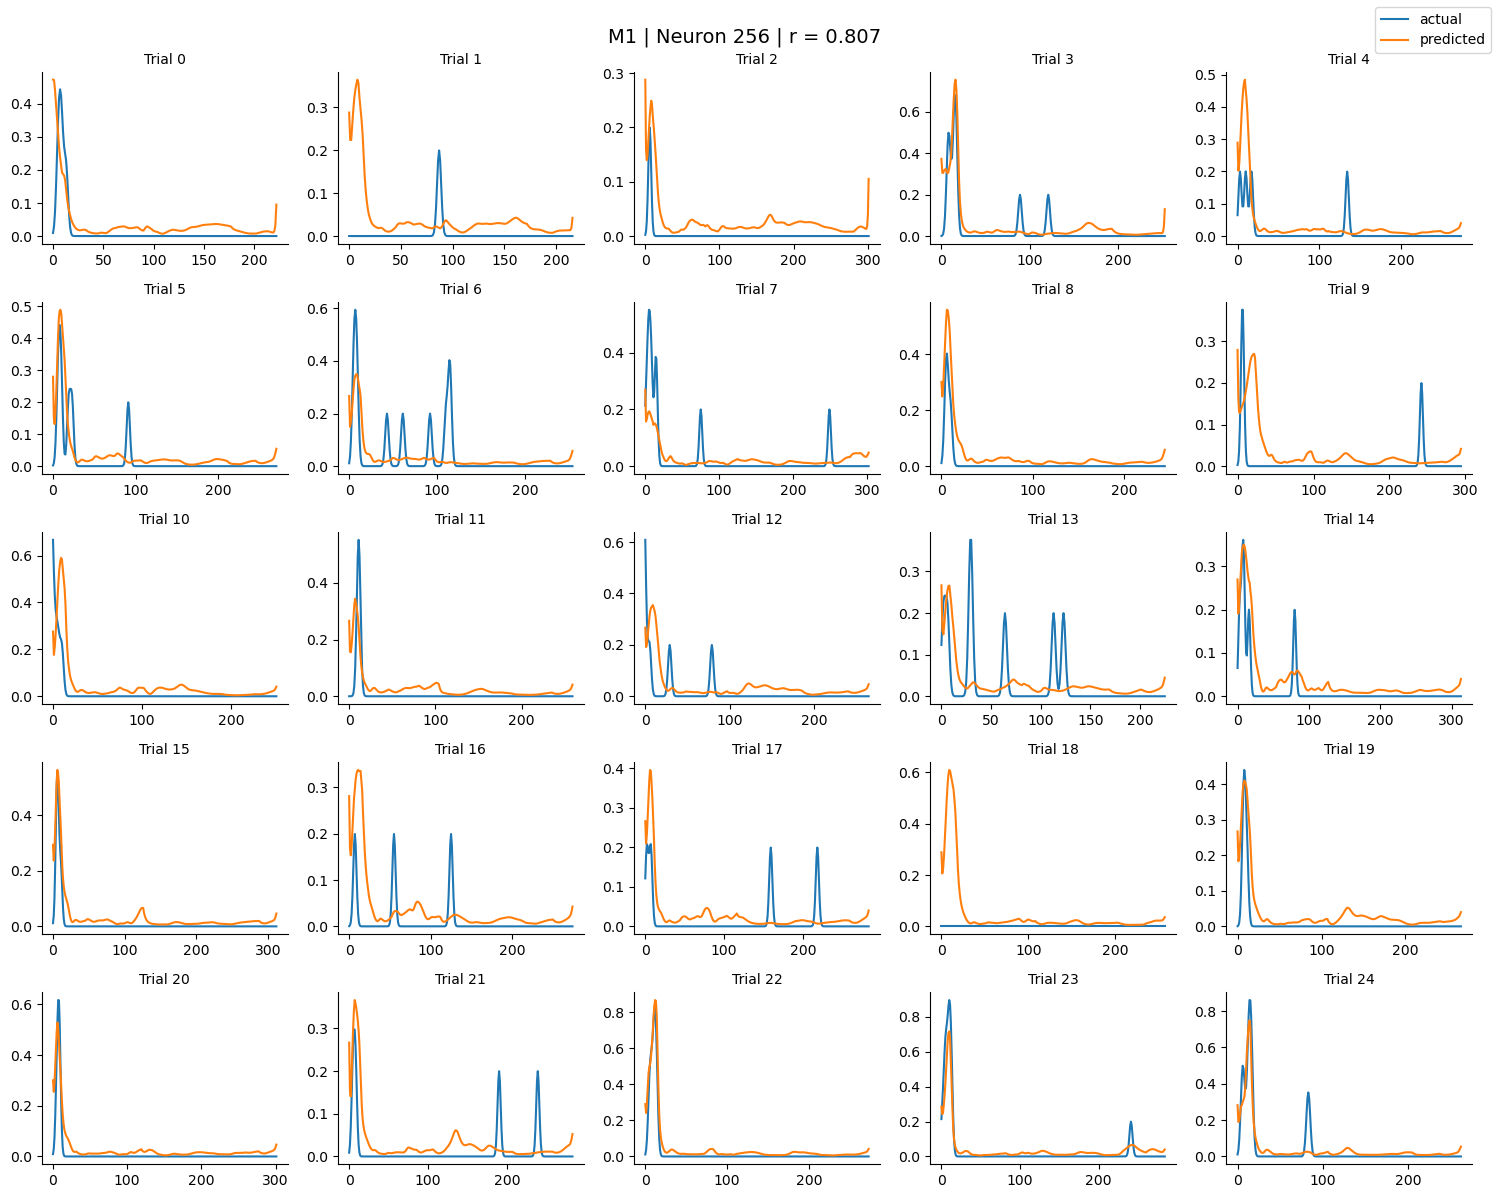

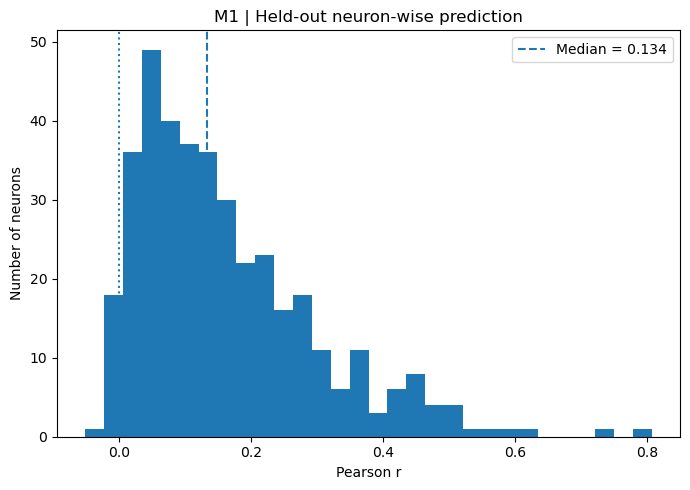

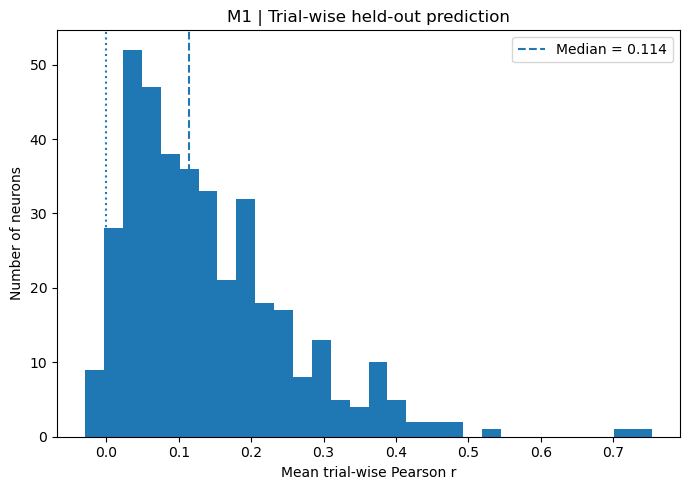

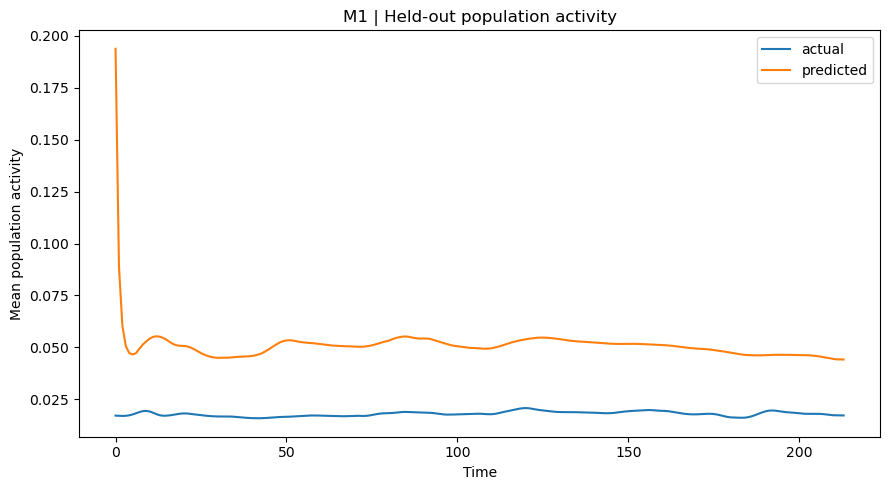

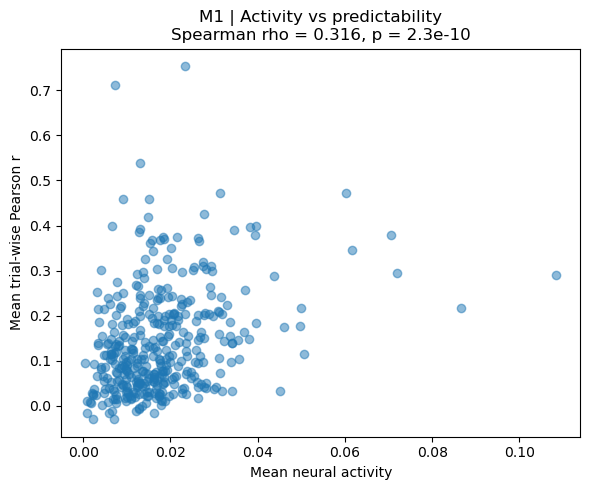

In [22]:
#M1 RESULTS PLOTS
###################

#find representative neurons for M1
neurons_m1 = get_representative_neurons(
    results_m1
)

print(neurons_m1)


## Make plots for M1

plot_example_trials(
    results_m1,
    Y_test_trials,
    neurons_m1["best"],
    "M1"
)

plot_neuron_r_distribution(
    results_m1,
    "M1"
)

plot_trial_r_distribution(
    results_m1,
    "M1"
)

plot_population_activity(
    results_m1,
    Y_test_trials,
    "M1"
)

plot_activity_vs_predictability(
    results_m1,
    Y_test_trials,
    "M1"
)

Model 2: Dale-constrained neural RNN - What changes when biologically plausible E/I structure is imposed?

In [23]:
# ============================================================
# M2 — Dale-constrained RNN
# ============================================================

model_m2 = create_model(
    dale=True,
    seed=0
)

history_m2 = train_neural_rnn(
    model=model_m2,
    X_train=X_train_trials_torch,
    Y_train=Y_train_trials_torch,
    y_train=y_train,
    beta=beta,
    lambda_neural=lambda_neural,
    lr=learning_rate,
    n_epochs=n_epochs,
    grad_clip=grad_clip
)

results_m2 = evaluate_model(
    model=model_m2,
    X_test=X_test_trials_torch,
    Y_test=Y_test_trials,
    y_test=y_test
)

Epoch 01/50 | Total: 141.677 | Choice: 39.716 | Neural: 20.392
Epoch 10/50 | Total: 34.328 | Choice: 23.028 | Neural: 2.260
Epoch 20/50 | Total: 26.968 | Choice: 16.336 | Neural: 2.126
Epoch 30/50 | Total: 21.591 | Choice: 11.380 | Neural: 2.042
Epoch 40/50 | Total: 18.962 | Choice: 9.015 | Neural: 1.989
Epoch 50/50 | Total: 16.725 | Choice: 7.002 | Neural: 1.945
========== NEURAL PREDICTION ==========
Mean neuron-wise r:   0.162
Median neuron-wise r: 0.130

========== TRIAL-WISE PREDICTION ==========
Mean trial-wise r:    0.138
Median trial-wise r:  0.113

========== CALIBRATION ==========
Actual mean activity:    0.01757
Predicted mean activity: 0.05356
Prediction bias:         +0.03599
Predicted / actual:      3.05x

========== BEHAVIOR ==========
Choice accuracy:         0.839
Majority-class baseline: 0.839
Balanced accuracy:       0.500
N trials:                62
Confusion matrix:
[[ 0 10]
 [ 0 52]]


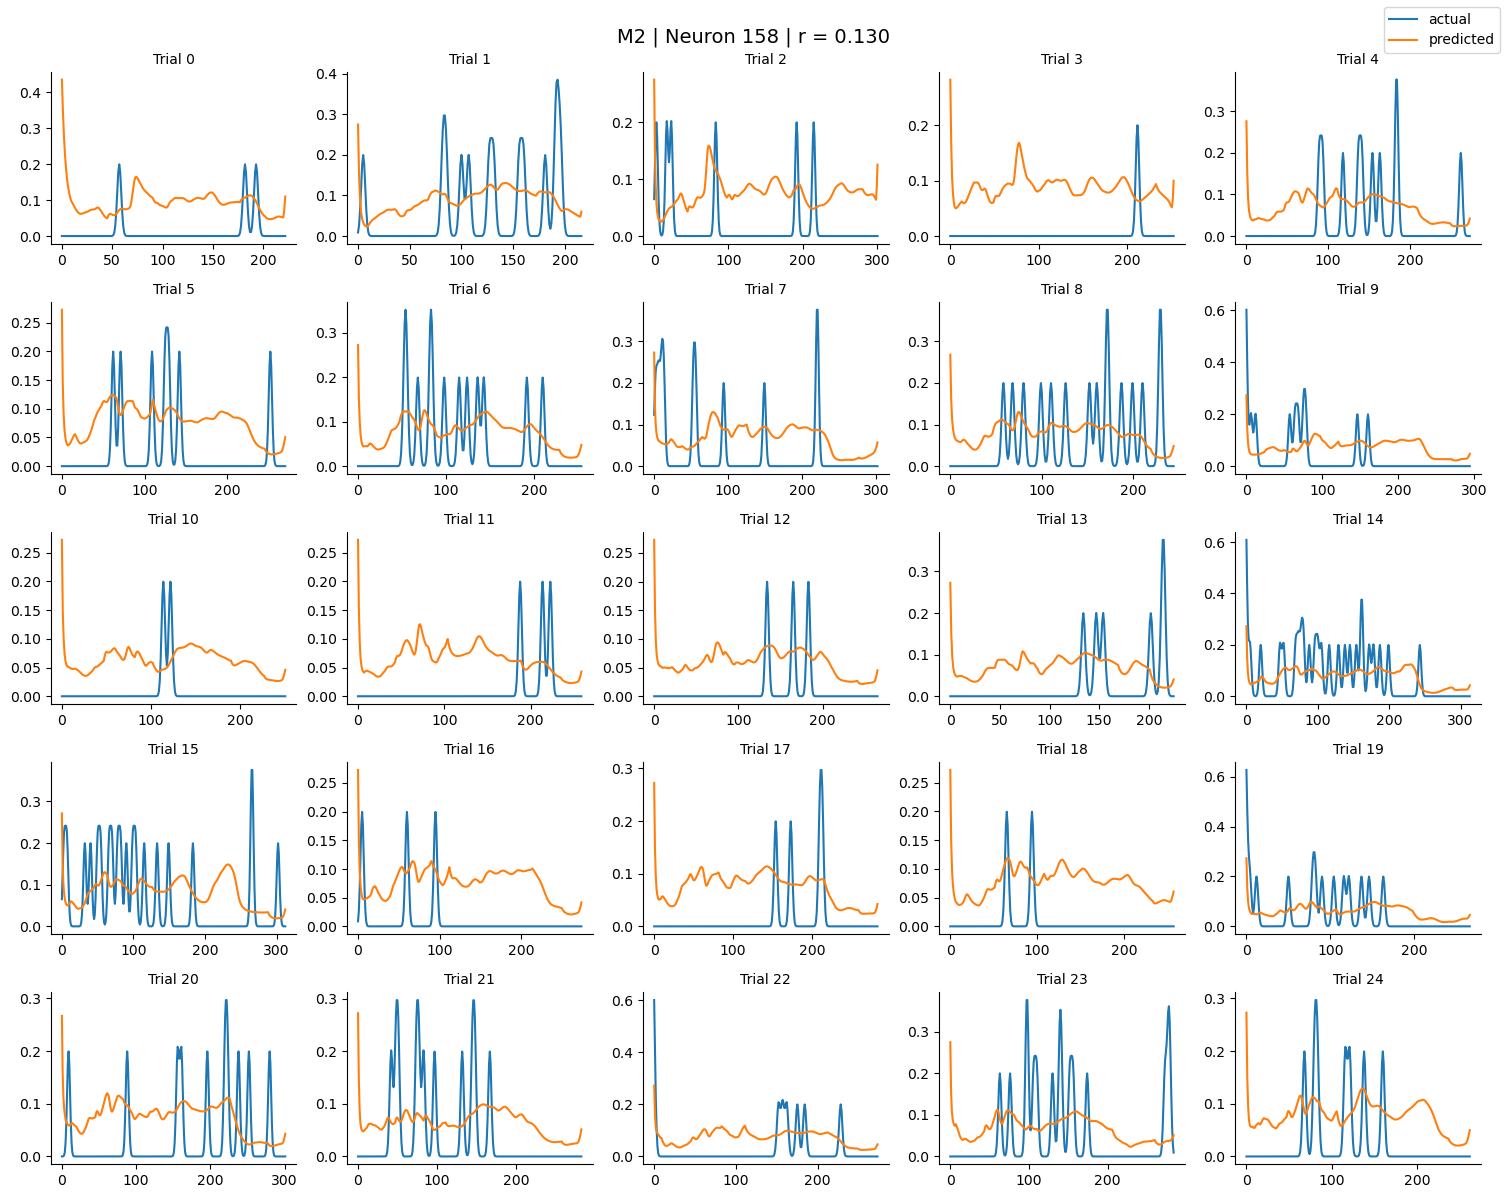

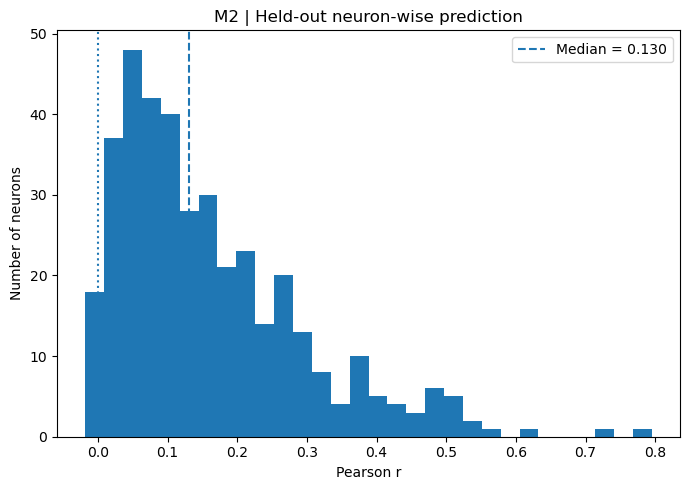

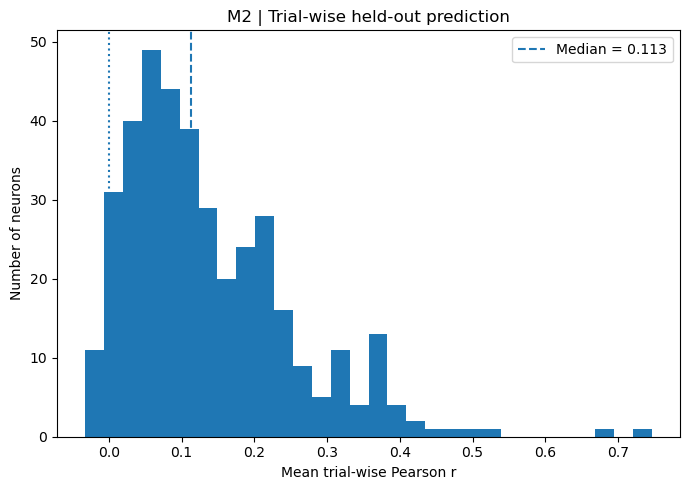

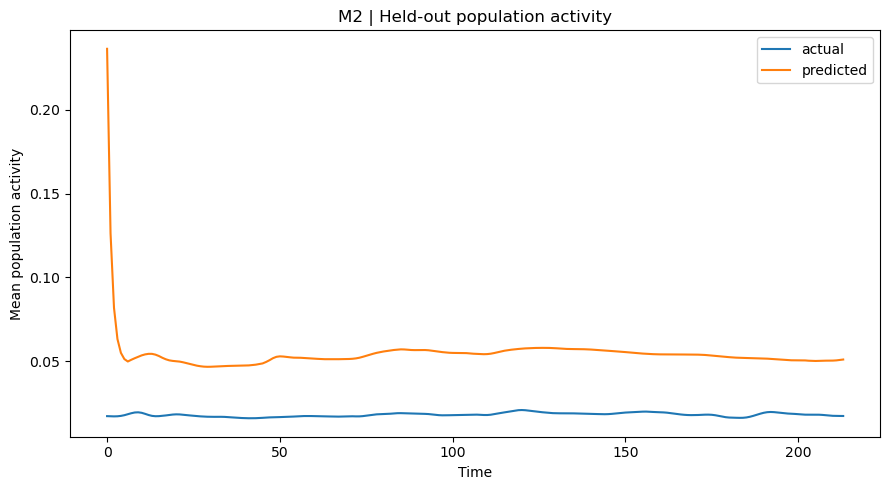

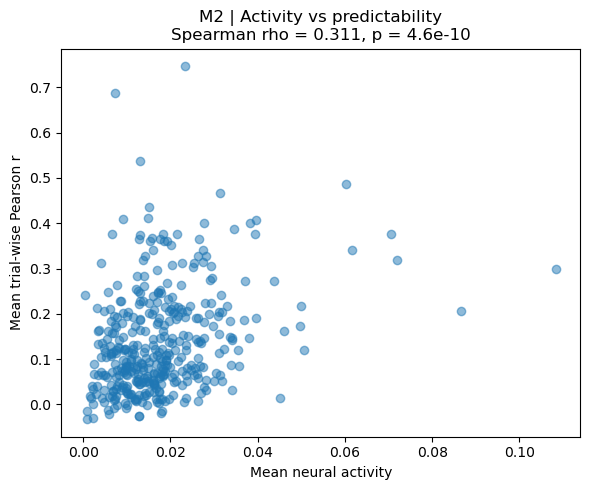

In [47]:
## mkae plots for M2
neurons_m2 = get_representative_neurons(
    results_m2
)

plot_example_trials(
    results_m2,
    Y_test_trials,
    neurons_m2["median"],
    "M2"
)

plot_neuron_r_distribution(
    results_m2,
    "M2"
)

plot_trial_r_distribution(
    results_m2,
    "M2"
)

plot_population_activity(
    results_m2,
    Y_test_trials,
    "M2"
)

plot_activity_vs_predictability(
    results_m2,
    Y_test_trials,
    "M2"
)

Let's look at all models across folds

In [41]:
# ============================================================
# 10-fold comparison: M0 vs M1 vs M2
# ============================================================

import pandas as pd
alpha=0.2
learning_rate=1e-3
cv_summary = []
cv_results = {}

for fold_number in range(10):

    print("\n" + "=" * 70)
    print(f"FOLD {fold_number + 1}/10")
    print("=" * 70)

    data = fold_data[fold_number]

    # ========================================================
    # Prepare this fold
    # ========================================================

    X_train_torch = [
        torch.tensor(x, dtype=torch.float32, device=device)
        for x in data["X_train"]
    ]

    X_test_torch = [
        torch.tensor(x, dtype=torch.float32, device=device)
        for x in data["X_test"]
    ]

    Y_train_torch = [
        torch.tensor(y, dtype=torch.float32, device=device)
        for y in data["Y_train"]
    ]

    # evaluate_model expects Y_test as NumPy arrays
    Y_test = data["Y_test"]

    y_train_fold = torch.tensor(
        data["correct_train"],
        dtype=torch.long,
        device=device
    )

    y_test_fold = torch.tensor(
        data["correct_test"],
        dtype=torch.long,
        device=device
    )

    input_dim_fold = X_train_torch[0].shape[1]

    cv_results[fold_number] = {}


    # ========================================================
    # M0 — behavior-only RNN
    # ========================================================

    print("\n--- M0 ---")

    torch.manual_seed(0)

    model_m0 = SimpleRateRNN(
        input_dim=input_dim_fold,
        hidden_dim=hidden_dim,
        output_dim=2,
        alpha=alpha
    ).to(device)

    history_m0 = train_m0(
        model=model_m0,
        X_train=X_train_torch,
        y_train=y_train_fold,
        n_epochs=5,
        lr=learning_rate
    )

    results_m0 = evaluate_m0(
        model=model_m0,
        X_test=X_test_torch,
        y_test=y_test_fold
    )

    cv_results[fold_number]["M0"] = {
        "history": history_m0,
        "results": results_m0
    }

    cv_summary.append({
        "fold": fold_number + 1,
        "model": "M0",

        "mean_neuron_r": np.nan,
        "median_neuron_r": np.nan,
        "mean_trial_r": np.nan,
        "median_trial_r": np.nan,

        "actual_mean": np.nan,
        "predicted_mean": np.nan,
        "prediction_bias": np.nan,
        "prediction_ratio": np.nan,

        "accuracy": results_m0["accuracy"],
        "majority_baseline": results_m0["majority_accuracy"],
        "balanced_accuracy": results_m0["balanced_accuracy"],

        "TN": results_m0["TN"],
        "FP": results_m0["FP"],
        "FN": results_m0["FN"],
        "TP": results_m0["TP"]
    })


    # ========================================================
    # M1 / M2
    # ========================================================

    for model_name, dale in [
        ("M1", False),
        ("M2", True)
    ]:

        print(f"\n--- {model_name} ---")

        model = create_model(
            dale=dale,
            seed=0
        )

        history = train_neural_rnn(
            model=model,
            X_train=X_train_torch,
            Y_train=Y_train_torch,
            y_train=y_train_fold,
            beta=beta,
            lambda_neural=lambda_neural,
            lr=learning_rate,
            n_epochs=n_epochs,
            grad_clip=grad_clip
        )

        results = evaluate_model(
            model=model,
            X_test=X_test_torch,
            Y_test=Y_test,
            y_test=y_test_fold
        )

        cv_results[fold_number][model_name] = {
            "history": history,
            "results": results
        }

        cm = results["confusion_matrix"]

        cv_summary.append({
            "fold": fold_number + 1,
            "model": model_name,

            "mean_neuron_r":
                np.nanmean(results["neuron_r"]),

            "median_neuron_r":
                np.nanmedian(results["neuron_r"]),

            "mean_trial_r":
                np.nanmean(results["mean_trial_r"]),

            "median_trial_r":
                np.nanmedian(results["mean_trial_r"]),

            "actual_mean":
                results["actual_mean"],

            "predicted_mean":
                results["predicted_mean"],

            "prediction_bias":
                results["prediction_bias"],

            "prediction_ratio":
                results["prediction_ratio"],

            "accuracy":
                results["choice_accuracy"],

            "majority_baseline":
                results["majority_baseline"],

            "balanced_accuracy":
                results["balanced_accuracy"],

            "TN": cm[0, 0],
            "FP": cm[0, 1],
            "FN": cm[1, 0],
            "TP": cm[1, 1]
        })


# ============================================================
# Convert summary to DataFrame
# ============================================================
cv_summary_df = pd.DataFrame(cv_summary)

print("\nFinished all folds.")
display(cv_summary_df)


FOLD 1/10

--- M0 ---

--- M1 ---
Epoch 01/50 | Total: 235.155 | Choice: 15.848 | Neural: 43.861
Epoch 10/50 | Total: 10.785 | Choice: 0.005 | Neural: 2.156
Epoch 20/50 | Total: 10.115 | Choice: 0.001 | Neural: 2.023
Epoch 30/50 | Total: 9.628 | Choice: 0.001 | Neural: 1.925
Epoch 40/50 | Total: 9.197 | Choice: 0.000 | Neural: 1.839
Epoch 50/50 | Total: 8.785 | Choice: 0.000 | Neural: 1.757
========== NEURAL PREDICTION ==========
Mean neuron-wise r:   0.161
Median neuron-wise r: 0.128

========== TRIAL-WISE PREDICTION ==========
Mean trial-wise r:    0.140
Median trial-wise r:  0.109

========== CALIBRATION ==========
Actual mean activity:    0.01757
Predicted mean activity: 0.05165
Prediction bias:         +0.03408
Predicted / actual:      2.94x

========== BEHAVIOR ==========
Choice accuracy:         1.000
Majority-class baseline: 0.823
Balanced accuracy:       1.000
N trials:                62
Confusion matrix:
[[11  0]
 [ 0 51]]

--- M2 ---
Epoch 01/50 | Total: 183.168 | Choice: 4

,fold,model,mean_neuron_r,median_neuron_r,mean_trial_r,median_trial_r,actual_mean,predicted_mean,prediction_bias,prediction_ratio,accuracy,majority_baseline,balanced_accuracy,TN,FP,FN,TP
0,1,M0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0.822581,1.0,11,0,0,51
1,1,M1,0.160981,0.127942,0.140211,0.108590,0.017565,0.051645,0.034080,2.940200,1.0,0.822581,1.0,11,0,0,51
2,1,M2,0.163372,0.129414,0.141673,0.113825,0.017565,0.052660,0.035095,2.997979,1.0,0.822581,1.0,11,0,0,51
3,2,M0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0.822581,1.0,11,0,0,51
4,2,M1,0.158449,0.121399,0.136788,0.107174,0.017970,0.054424,0.036453,3.028508,1.0,0.822581,1.0,11,0,0,51
5,2,M2,0.027326,0.012568,0.135931,0.101409,0.017970,0.096376,0.078405,5.363020,1.0,0.822581,1.0,11,0,0,51
6,3,M0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0.822581,1.0,11,0,0,51
7,3,M1,0.154469,0.121752,0.134438,0.109078,0.017420,0.052522,0.035103,3.015108,1.0,0.822581,1.0,11,0,0,51
8,3,M2,0.155185,0.117376,0.135271,0.111976,0.017420,0.055140,0.037720,3.165382,1.0,0.822581,1.0,11,0,0,51
9,4,M0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0.822581,1.0,11,0,0,51


In [ ]:
cv_summary_df.to_csv( #V:\Connie\ProcessedData\HA11-1R\2023-05-05\GLM_3nmf_pre\prepost trial cv 73 #10\test
    "m012_10fold_summary.csv",
    index=False
)

torch.save(
    cv_results,
    "m012_10fold_full_results.pt"
)

In [43]:
import os
print(os.getcwd())

V:\Connie\ProcessedData\HA11-1R\2023-05-05\GLM_3nmf_pre\prepost trial cv 73 #10\test


Cells below were used for priminary testing

In [27]:
# ============================================================
# Latent E/I composition for M2
# ============================================================

n_pyr = int(0.70 * hidden_dim)
n_pv  = int(0.20 * hidden_dim)
n_som = hidden_dim - n_pyr - n_pv

dale_sign = torch.cat([
    torch.ones(n_pyr),
    -torch.ones(n_pv),
    -torch.ones(n_som)
]).to(device)

print(
    f"Latent units: "
    f"{n_pyr} excitatory, "
    f"{n_pv} PV-like inhibitory, "
    f"{n_som} SOM-like inhibitory"
)

Latent units: 89 excitatory, 25 PV-like inhibitory, 14 SOM-like inhibitory


In [28]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class DaleRateRNN(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim,
                 n_neurons,  # number of recorded neurons to predict
                 dale_sign,  # Tensor [hidden_dim], +1 for Pyr, -1 for PV/SOM
                 alpha=0.2):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.alpha = alpha

        # Input weights (unconstrained)
        self.W_in = nn.Linear(input_dim, hidden_dim, bias=True)

        # Recurrent weights: learn unconstrained Theta, transform to Dale matrix
        self.Theta_rec = nn.Parameter(torch.randn(hidden_dim, hidden_dim) * 0.05)
        self.register_buffer("dale_sign", dale_sign.view(hidden_dim, 1))  # [N,1]

        # Choice readout (from final state)
        self.W_out = nn.Linear(hidden_dim, output_dim)

        # Neural activity readout (from each timepoint)
        self.C = nn.Linear(hidden_dim, n_neurons, bias=True)

    def W_rec(self):
        W_pos = F.softplus(self.Theta_rec)           # >= 0
        return self.dale_sign * W_pos                # rows sign-constrained

    def forward_trial(self, X):
        T = X.shape[0]
        h = torch.zeros(self.hidden_dim, device=X.device)

        hs = []
        yhats = []

        Wrec = self.W_rec()

        for t in range(T):
            pre = (Wrec @ h) + self.W_in(X[t])
            h = (1 - self.alpha) * h + self.alpha * torch.tanh(pre)

            hs.append(h)

            # IMPORTANT: raw logits (no sigmoid here)
            yhat_t = F.softplus(self.C(h)) #self.C(h) < this one is unconstrained, but we want to enforce non-negativity for firing rates
            
            yhats.append(yhat_t)

        hs = torch.stack(hs, dim=0)         # [T, hidden_dim]
        yhat_logits = torch.stack(yhats, dim=0)  # [T, n_neurons]

        logits = self.W_out(h)

        return logits, hs, yhat_logits



hidden_dim = 128
n_pyr = int(0.7 * hidden_dim)
n_pv  = int(0.2 * hidden_dim)
n_som = hidden_dim - n_pyr - n_pv

dale_sign = torch.cat([
    torch.ones(n_pyr),
    -torch.ones(n_pv),
    -torch.ones(n_som)
]).to(device)


In [29]:


y_neural_train =  [
    torch.tensor(Y, dtype=torch.float32, device=device)
    for Y in Y_train_trials ] 


model = DaleRateRNN(
    input_dim=input_dim,
    hidden_dim=hidden_dim,
    output_dim=2,                # correct / incorrect
    n_neurons=y_neural_train[0].shape[1],
    dale_sign=dale_sign,
    alpha=0.2
).to(device)


#Loss functions + optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

criterion_choice = nn.CrossEntropyLoss()
# criterion_neural = nn.MSELoss()
# criterion_neural = nn.BCELoss()
# pos_rate = np.array(Y_train_trials).mean().item()  # ~0.025 from earlier #what we are doing here is scaling things? based on the mean spikes per frame (~2.5% of neurons have spikes per frame)
# pos_weight = torch.tensor((1 - pos_rate) / pos_rate, device=device)
# pos_weight = torch.tensor(39.0, device=device)
criterion_neural = nn.MSELoss()#nn.BCEWithLogitsLoss() #(pos_weight=pos_weight)


lambda_neural = 5.0   # 1.0 start here, tune later (was doing 50 before)




In [30]:
#Training loop
n_epochs = 50

for epoch in range(n_epochs):

    model.train()
    total_loss = 0
    total_choice_loss = 0
    total_neural_loss = 0

    for k in range(len(X_train_trials_torch)):

        X_trial = X_train_trials_torch[k]
        Y_trial = y_neural_train[k]

        optimizer.zero_grad()

        logits, hidden_states, yhat = model.forward_trial(X_trial)

        # ----- Choice loss (trial-level) -----
        loss_choice = criterion_choice(
            logits.unsqueeze(0),
            y_train[k].unsqueeze(0)
        )

        # ----- Weighted neural prediction loss -----

        beta = 20 #test different values of beta to see how it affects the weighting of neural events, (5,10,20,25,50)

        # Larger neural events receive more weight
        weights = 1.0 + beta * Y_trial

        # Squared error at every timepoint x neuron
        squared_error = (yhat - Y_trial) ** 2

        # Weighted MSE
        loss_neural = (weights * squared_error).sum() / weights.sum()

        # ----- Combined loss -----
        loss = loss_choice + lambda_neural * loss_neural

        # # ----- Neural prediction loss (time-resolved) -----
        # loss_neural = criterion_neural(yhat, Y_trial)

        # # ----- Combined loss -----
        # loss = lambda_neural * loss_neural#loss_choice + lambda_neural * loss_neural

        loss.backward()

        # optional: gradient clipping for stability
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()

        total_loss += loss.item()
        total_choice_loss += loss_choice.item()
        total_neural_loss += loss_neural.item()

    print(
        f"Epoch {epoch:02d} | "
        f"Total {total_loss:.3f} | "
        f"Choice {total_choice_loss:.3f} | "
        f"Neural {total_neural_loss:.3f}"
    )


Epoch 00 | Total 121.313 | Choice 46.805 | Neural 14.902
Epoch 01 | Total 50.711 | Choice 37.614 | Neural 2.619
Epoch 02 | Total 50.680 | Choice 37.578 | Neural 2.620
Epoch 03 | Total 50.741 | Choice 37.629 | Neural 2.622
Epoch 04 | Total 50.781 | Choice 37.661 | Neural 2.624
Epoch 05 | Total 50.810 | Choice 37.686 | Neural 2.625
Epoch 06 | Total 50.834 | Choice 37.706 | Neural 2.626
Epoch 07 | Total 50.853 | Choice 37.724 | Neural 2.626
Epoch 08 | Total 50.868 | Choice 37.739 | Neural 2.626
Epoch 09 | Total 50.879 | Choice 37.751 | Neural 2.626
Epoch 10 | Total 50.888 | Choice 37.762 | Neural 2.625
Epoch 11 | Total 50.894 | Choice 37.772 | Neural 2.625
Epoch 12 | Total 50.899 | Choice 37.780 | Neural 2.624
Epoch 13 | Total 50.901 | Choice 37.786 | Neural 2.623
Epoch 14 | Total 50.902 | Choice 37.792 | Neural 2.622
Epoch 15 | Total 50.901 | Choice 37.797 | Neural 2.621
Epoch 16 | Total 50.900 | Choice 37.801 | Neural 2.620
Epoch 17 | Total 50.897 | Choice 37.805 | Neural 2.618
Epoch 18

In [31]:
import scipy
def load_celltypes(server,animalID,date):
    base_path = f"{server}/Connie/ProcessedData/{animalID}/{date}/"


    path = os.path.join(base_path, 'red_variables/')
    pyr_str = scipy.io.loadmat(path+'pyr_cells.mat')
    pyr = pyr_str['pyr_cells']-1 #convert to python indices
    pyr = np.transpose(pyr)

    som_str = scipy.io.loadmat(path+'mcherry_cells.mat')
    som = som_str['mcherry_cells']-1

    pv_str = scipy.io.loadmat(path+'tdtom_cells.mat')
    pv = pv_str['tdtom_cells']-1


    neuron_groups = {
        'pyr': pyr,
        'som': som,
        'pv': pv}

    # Define colors for each group
    colors = {'pyr': (0.37, 0.75, 0.49),   # pyr = 0
            'som': (0.17, 0.35, 0.8),    # som = 1
            'pv': (0.82, 0.04, 0.04)}    # pv = 2

    #combine celltypes into different indices
    celltype_array = np.zeros(np.shape(np.concatenate((pyr,som,pv)))[0])
    celltype_array[som] = 1
    celltype_array[pv] = 2

    return celltype_array, neuron_groups, colors

celltype_array, neuron_groups, colors = load_celltypes('V:',mouse,date)

In [32]:
#sanity checks
#(1) variance explained by the model
with torch.no_grad():
    logits, hs, yhat = model.forward_trial(X_trial)

r2 = 1 - torch.var(Y_trial - yhat) / torch.var(Y_trial)
print("Example R²:", r2.item())

print("Mean predicted:", yhat.mean().item())
print("Mean actual:", Y_trial.mean().item())

#(2) check that signs make sense
Wrec = model.W_rec().detach()

print("Min Pyr row:", Wrec[:n_pyr].min()) #SHOULD BE POSITIVE NUMBER
print("Max PV row:", Wrec[n_pyr:n_pyr+n_pv].max()) #SHOULD BE NEGATIVE NUMBER



#(3) split neural loss by cell type
pyr_idx = neuron_groups['pyr']
pv_idx = neuron_groups['pv']
som_idx = neuron_groups['som']

loss_neural = (
    criterion_neural(yhat[:, pyr_idx], Y_trial[:, pyr_idx]) +
    criterion_neural(yhat[:, pv_idx],  Y_trial[:, pv_idx]) +
    criterion_neural(yhat[:, som_idx], Y_trial[:, som_idx])
)

print(loss_neural)


Example R²: -0.12440824508666992
Mean predicted: 0.058627936989068985
Mean actual: 0.025269974023103714
Min Pyr row: tensor(0.5951)
Max PV row: tensor(-0.6132)
tensor(0.0212)


In [34]:
from scipy.stats import pearsonr
import numpy as np

Y_np = Y_trial.detach().cpu().numpy()
Yhat_np = yhat.detach().cpu().numpy()

r_all = []

for n in range(Y_np.shape[1]):

    target = Y_np[:, n]
    pred = Yhat_np[:, n]

    if np.std(target) > 0 and np.std(pred) > 0:
        r, _ = pearsonr(target, pred)
        r_all.append(r)

r_all = np.array(r_all)

print("Mean r:", np.mean(r_all))
print("Median r:", np.median(r_all))
print("% neurons r > 0:", np.mean(r_all > 0) * 100)
print("% neurons r > 0.2:", np.mean(r_all > .2) * 100)
print("% neurons r > 0.3:", np.mean(r_all > .3) * 100)



Mean r: 0.03722798504428096
Median r: -0.038178739110233444
% neurons r > 0: 26.956521739130434
% neurons r > 0.2: 14.492753623188406
% neurons r > 0.3: 10.144927536231885


In [35]:
# run code on test trials (active context)
# Convert test inputs to PyTorch tensors
X_test_trials_torch = [
    torch.tensor(X, dtype=torch.float32, device=device)
    for X in X_test_trials
]

# Put trained model into evaluation mode
model.eval()

yhat_test = []
hidden_states_test = []
logits_test = []

# Predict neural activity on held-out test trials
with torch.no_grad():

    for X_trial in X_test_trials_torch:

        logits, hidden_states, yhat = model.forward_trial(X_trial)

        yhat_test.append(yhat.cpu().numpy())
        hidden_states_test.append(hidden_states.cpu().numpy())
        logits_test.append(logits.cpu().numpy())

print("Number of test trials:", len(yhat_test))
print("Example prediction shape:", yhat_test[0].shape)
print("Actual neural data shape:", Y_test_trials[0].shape)

Number of test trials: 62
Example prediction shape: (223, 385)
Actual neural data shape: (223, 385)


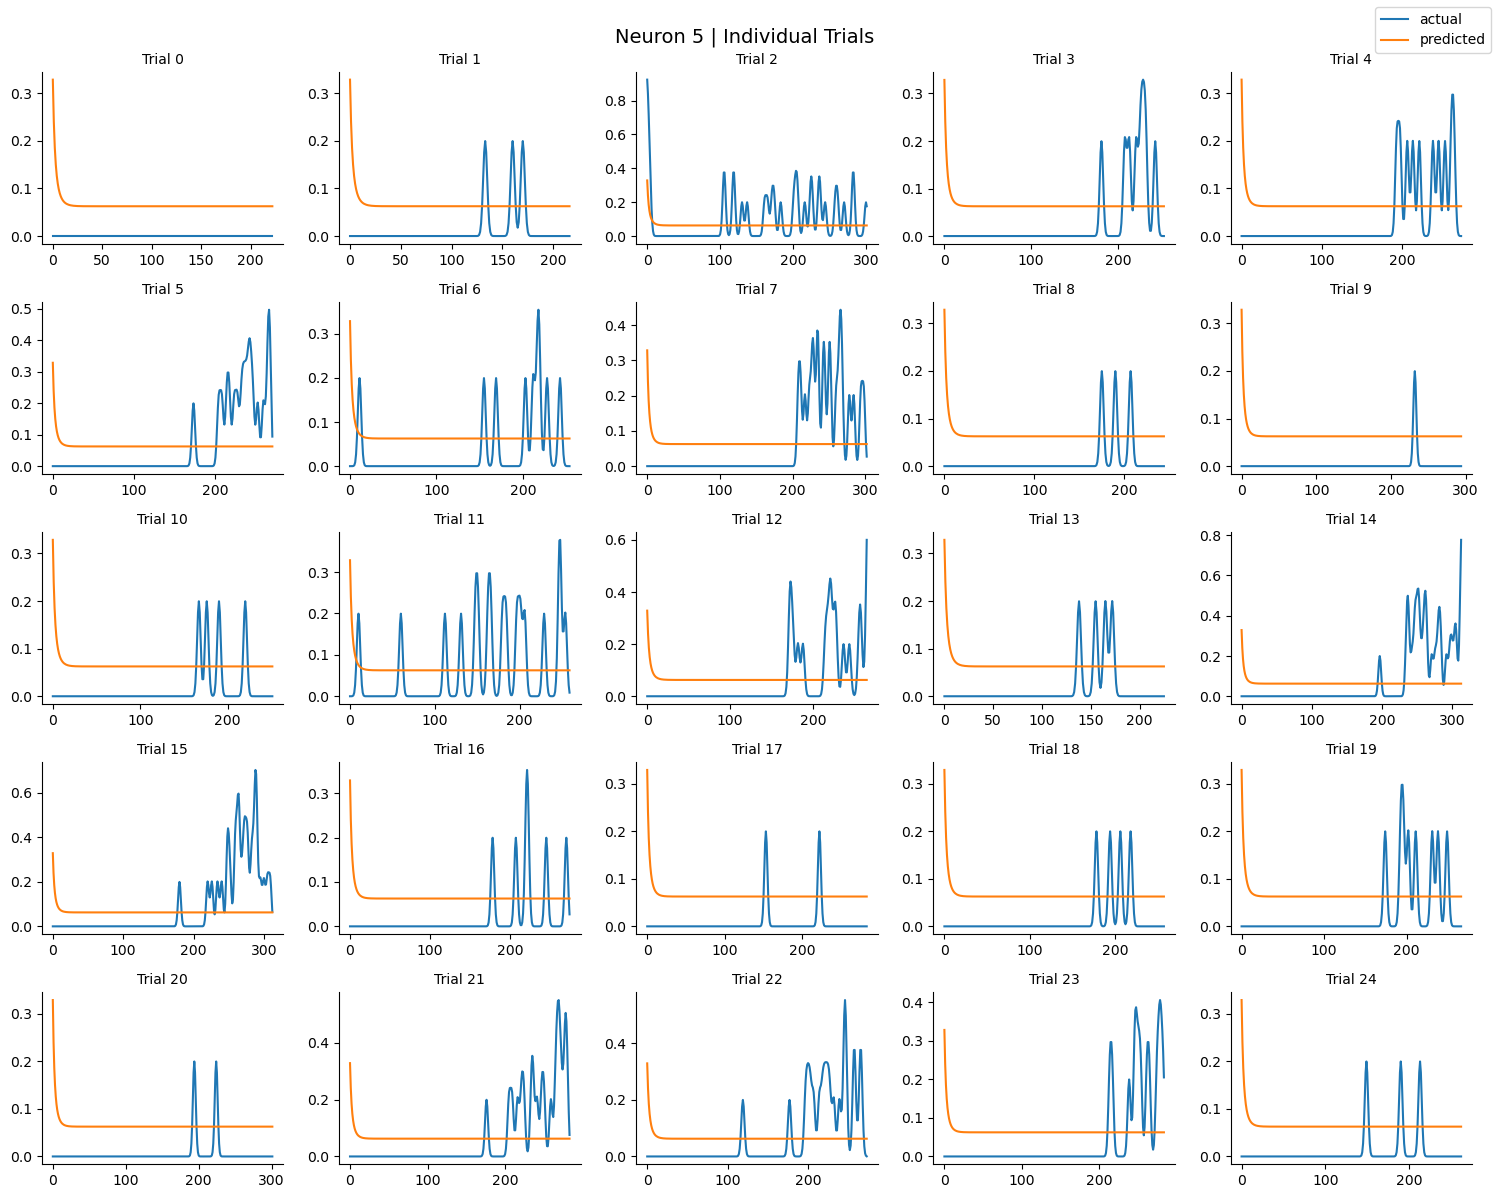

In [36]:
#plot single trials for example neuron!
import numpy as np
import matplotlib.pyplot as plt

neuron = 5  # Specify neuron index
n_trials = min(25, len(Y_test_trials))

# --- Plot individual trials (5x5) ---
fig, axes = plt.subplots(5, 5, figsize=(15, 12))
axes = axes.flatten()

for trial in range(n_trials):

    axes[trial].plot(
        Y_test_trials[trial][:, neuron],
        label="actual"
    )

    axes[trial].plot(
        yhat_test[trial][:, neuron],
        label="predicted"
    )

    axes[trial].set_title(f"Trial {trial}", fontsize=10)

   
    axes[trial].spines["top"].set_visible(False)
    axes[trial].spines["right"].set_visible(False)

for ax in axes[n_trials:]:
    ax.set_visible(False)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right")

fig.suptitle(f"Neuron {neuron} | Individual Trials", fontsize=14)
plt.tight_layout()

plt.show()



# # --- Plot mean activity across trials ---
# # Stack trials: (trials, timepoints)
# actual = np.stack([
#     Y_test_trials[trial][:, neuron]
#     for trial in range(n_trials)
# ])

# predicted = np.stack([
#     yhat_test[trial][:, neuron]
#     for trial in range(n_trials)
# ])

# # Mean across trials
# mean_actual = np.mean(actual, axis=0)
# mean_predicted = np.mean(predicted, axis=0)

# # --- Plot ---
# plt.figure(figsize=(6, 4))

# plt.plot(mean_actual, label="Mean actual", color="black")
# plt.plot(mean_predicted, label="Mean predicted", color="red")

# plt.xlabel("Time")
# plt.ylabel("Activity")
# plt.title(f"Neuron {neuron} | Mean Across {n_trials} Trials")
# plt.legend()
# plt.tight_layout()
# plt.show()


In [37]:
from scipy.stats import pearsonr
import numpy as np

n_neurons = Y_test_trials[0].shape[1]

r_test = np.full(n_neurons, np.nan)

for n in range(n_neurons):

    actual = []
    predicted = []

    for trial in range(len(Y_test_trials)):

        actual.append(Y_test_trials[trial][:, n])
        predicted.append(yhat_test[trial][:, n])

    actual = np.concatenate(actual)
    predicted = np.concatenate(predicted)

    if np.std(actual) > 0 and np.std(predicted) > 0:
        r_test[n] = pearsonr(actual, predicted)[0]

print("Mean test r:", np.nanmean(r_test))
print("Median test r:", np.nanmedian(r_test))
print("% neurons r > 0:", np.mean(r_test[~np.isnan(r_test)] > 0) * 100)
print("% neurons r > 0.2:", np.mean(r_test[~np.isnan(r_test)] > 0.2) * 100)
print("% neurons r > 0.3:", np.mean(r_test[~np.isnan(r_test)] > 0.3) * 100)

print("\nNeuron 5 test r:", r_test[5])
print("Neuron 3 test r:", r_test[3])

# this tells use that train vs test r are similar, so model is not overfitting to training data
# train seems better than test for high r neurons

Mean test r: 0.0013743399633768837
Median test r: -0.0049558585107358985
% neurons r > 0: 44.675324675324674
% neurons r > 0.2: 0.5194805194805194
% neurons r > 0.3: 0.0

Neuron 5 test r: -0.032709766285376696
Neuron 3 test r: 0.013368733098175538


In [38]:
#testing if across vs within trial correlations are similar, to see if model is overfitting to trial idiosyncrasies
from scipy.stats import pearsonr
import numpy as np

n_neurons = Y_test_trials[0].shape[1]

trial_r = [[] for _ in range(n_neurons)]

for k in range(len(Y_test_trials)):

    Y = Y_test_trials[k]
    Yhat = yhat_test[k]

    for n in range(n_neurons):

        actual = Y[:, n]
        predicted = Yhat[:, n]

        if np.std(actual) > 0 and np.std(predicted) > 0:
            r = pearsonr(actual, predicted)[0]
            trial_r[n].append(r)

mean_trial_r = np.array([
    np.mean(r) if len(r) > 0 else np.nan
    for r in trial_r
])

print("Mean neuron-wise trial r:", np.nanmean(mean_trial_r))
print("Median neuron-wise trial r:", np.nanmedian(mean_trial_r))

print("\nNeuron 5 mean trial r:", mean_trial_r[5])
print("Neuron 3 mean trial r:", mean_trial_r[3])

Mean neuron-wise trial r: 0.0002789663603347316
Median neuron-wise trial r: -0.006364062415102525

Neuron 5 mean trial r: -0.04490294340526123
Neuron 3 mean trial r: 0.015285282026383924


Mean valid trials/neuron: 51.28051948051948
Median valid trials/neuron: 55.0
Min: 6
Max: 62

Neuron 5 valid trials: 60
Neuron 3 valid trials: 55


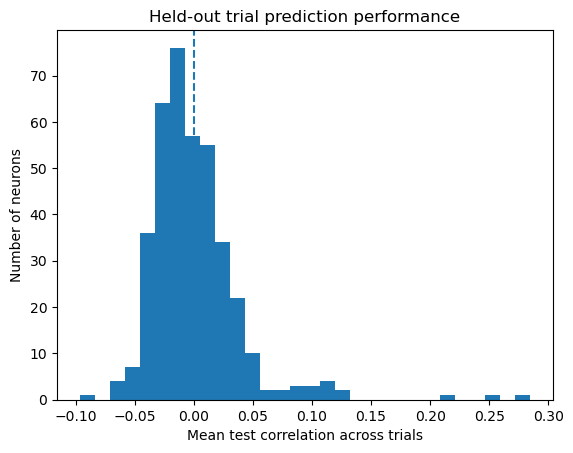

In [39]:
#checking valid trials per neuron
valid_trials_per_neuron = np.array([
    len(r) for r in trial_r
])

print("Mean valid trials/neuron:", np.mean(valid_trials_per_neuron))
print("Median valid trials/neuron:", np.median(valid_trials_per_neuron))
print("Min:", np.min(valid_trials_per_neuron))
print("Max:", np.max(valid_trials_per_neuron))

print("\nNeuron 5 valid trials:", valid_trials_per_neuron[5])
print("Neuron 3 valid trials:", valid_trials_per_neuron[3])


import matplotlib.pyplot as plt

plt.hist(mean_trial_r[~np.isnan(mean_trial_r)], bins=30)
plt.axvline(0, linestyle="--")

plt.xlabel("Mean test correlation across trials")
plt.ylabel("Number of neurons")
plt.title("Held-out trial prediction performance")
plt.show()

PYR: mean r = 0.001, median = -0.005, n = 324
PV:  mean r = -0.008, median = -0.009, n = 43
SOM: mean r = -0.005, median = -0.012, n = 15


C:\Users\runyan1\AppData\Local\Temp\ipykernel_35924\1011169289.py:29: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=['PYR', 'PV', 'SOM'], showfliers=False)


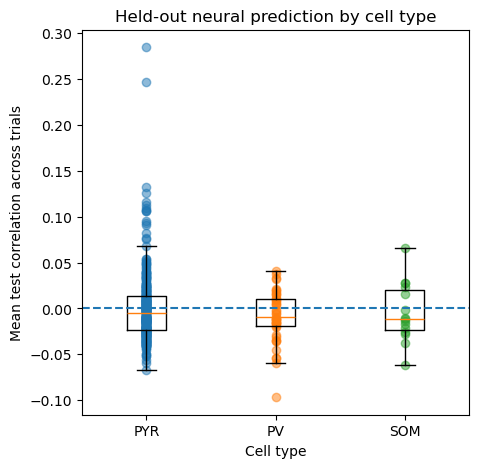

In [40]:
#compare prediction performance across cell types
pyr_r = mean_trial_r[neuron_groups['pyr']]
pv_r  = mean_trial_r[neuron_groups['pv']]
som_r = mean_trial_r[neuron_groups['som']]

# optionally require a reasonable number of valid test trials
min_trials = 10

pyr_idx = neuron_groups['pyr']
pv_idx  = neuron_groups['pv']
som_idx = neuron_groups['som']

pyr_r = mean_trial_r[pyr_idx][valid_trials_per_neuron[pyr_idx] >= min_trials]
pv_r  = mean_trial_r[pv_idx][valid_trials_per_neuron[pv_idx] >= min_trials]
som_r = mean_trial_r[som_idx][valid_trials_per_neuron[som_idx] >= min_trials]

print(f"PYR: mean r = {np.nanmean(pyr_r):.3f}, "
      f"median = {np.nanmedian(pyr_r):.3f}, n = {len(pyr_r)}")

print(f"PV:  mean r = {np.nanmean(pv_r):.3f}, "
      f"median = {np.nanmedian(pv_r):.3f}, n = {len(pv_r)}")

print(f"SOM: mean r = {np.nanmean(som_r):.3f}, "
      f"median = {np.nanmedian(som_r):.3f}, n = {len(som_r)}")

#visualize cell-type differences in prediction performance
plt.figure(figsize=(5, 5))
data = [pyr_r, pv_r, som_r]
plt.boxplot(data, labels=['PYR', 'PV', 'SOM'], showfliers=False)

# show individual neurons too
for x, vals in enumerate(data, start=1):
    plt.scatter(
        np.full(len(vals), x),
        vals,
        alpha=0.5
    )

plt.axhline(0, linestyle='--')
plt.ylabel("Mean test correlation across trials")
plt.xlabel("Cell type")
plt.title("Held-out neural prediction by cell type")
plt.show()

Activity vs prediction
Spearman rho: -0.23664897785689384
p: 2.915307241450613e-06


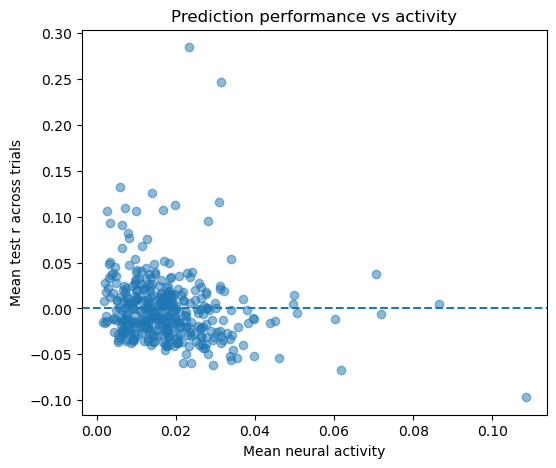

In [41]:
# Mean activity for every neuron across TEST trials
activity_sum = np.zeros(n_neurons)
sample_count = np.zeros(n_neurons)

for Y in Y_test_trials:
    activity_sum += Y.sum(axis=0)
    sample_count += Y.shape[0]

mean_activity = activity_sum / sample_count

# Only neurons included in our trial-wise analysis
valid = (
    ~np.isnan(mean_trial_r) &
    (valid_trials_per_neuron >= 10)
)

from scipy.stats import spearmanr

rho, p = spearmanr(
    mean_activity[valid],
    mean_trial_r[valid]
)

print("Activity vs prediction")
print("Spearman rho:", rho)
print("p:", p)

plt.figure(figsize=(6,5))
plt.scatter(
    mean_activity[valid],
    mean_trial_r[valid],
    alpha=0.5
)

plt.axhline(0, linestyle="--")
plt.xlabel("Mean neural activity")
plt.ylabel("Mean test r across trials")
plt.title("Prediction performance vs activity")
plt.show()

In [42]:
import numpy as np
import torch
from scipy.stats import pearsonr

# ============================================================
# Evaluate model on held-out trials
# ============================================================

model.eval()

all_Y = []
all_Yhat = []

trial_r = [[] for _ in range(Y_test_trials[0].shape[1])]

choice_preds = []
choice_actual = []

with torch.no_grad():

    for k in range(len(X_test_trials_torch)):

        # ----- Input -----
        X = X_test_trials_torch[k]

        # Y_test_trials is already numpy
        Y = Y_test_trials[k]

        # ----- Model prediction -----
        logits, hidden_states, yhat = model.forward_trial(X)

        # Your yhat appears to already be numpy in your current setup.
        # This handles either numpy OR torch safely.
        if torch.is_tensor(yhat):
            Yhat = yhat.detach().cpu().numpy()
        else:
            Yhat = np.asarray(yhat)

        # ====================================================
        # Store neural predictions
        # ====================================================

        all_Y.append(Y)
        all_Yhat.append(Yhat)

        # ====================================================
        # Trial-wise neural correlations
        # ====================================================

        for n in range(Y.shape[1]):

            actual = Y[:, n]
            predicted = Yhat[:, n]

            if np.std(actual) > 0 and np.std(predicted) > 0:
                r = pearsonr(actual, predicted)[0]

                if np.isfinite(r):
                    trial_r[n].append(r)

        # ====================================================
        # Behavioral prediction
        # ====================================================

        pred_choice = torch.argmax(logits).item()

        choice_preds.append(pred_choice)
        choice_actual.append(int(correct_test[k]))


# ============================================================
# Concatenate trials
# ============================================================

Y_all = np.concatenate(all_Y, axis=0)
Yhat_all = np.concatenate(all_Yhat, axis=0)

n_neurons = Y_all.shape[1]


# ============================================================
# 1. NEURON-WISE CORRELATION
#
# Concatenate all held-out trials, then calculate one r/neuron
# ============================================================

neuron_r = np.full(n_neurons, np.nan)

for n in range(n_neurons):

    actual = Y_all[:, n]
    predicted = Yhat_all[:, n]

    if np.std(actual) > 0 and np.std(predicted) > 0:

        r = pearsonr(actual, predicted)[0]

        if np.isfinite(r):
            neuron_r[n] = r


print("\n========== NEURAL PREDICTION ==========")

print(
    f"Mean neuron-wise r:   {np.nanmean(neuron_r):.3f}"
)

print(
    f"Median neuron-wise r: {np.nanmedian(neuron_r):.3f}"
)


# ============================================================
# 2. TRIAL-WISE CORRELATION
#
# Calculate r separately on each trial, then average within
# each neuron.
# ============================================================

mean_trial_r = np.array([
    np.mean(rs) if len(rs) > 0 else np.nan
    for rs in trial_r
])

print("\n========== TRIAL-WISE PREDICTION ==========")

print(
    f"Mean trial-wise r:    {np.nanmean(mean_trial_r):.3f}"
)

print(
    f"Median trial-wise r:  {np.nanmedian(mean_trial_r):.3f}"
)


# ============================================================
# 3. CALIBRATION
#
# Is the model predicting approximately the correct amount
# of activity overall?
# ============================================================

actual_mean = np.mean(Y_all)
predicted_mean = np.mean(Yhat_all)

mean_bias = predicted_mean - actual_mean

print("\n========== CALIBRATION ==========")

print(f"Actual mean activity:    {actual_mean:.5f}")
print(f"Predicted mean activity: {predicted_mean:.5f}")
print(f"Prediction bias:         {mean_bias:+.5f}")
print(
    f"Predicted / actual:      "
    f"{predicted_mean / actual_mean:.2f}x"
)


# ============================================================
# 4. BEHAVIORAL PERFORMANCE
# ============================================================

choice_preds = np.asarray(choice_preds)
choice_actual = np.asarray(choice_actual)

choice_accuracy = np.mean(choice_preds == choice_actual)

# Majority-class baseline
p_correct = np.mean(choice_actual)
chance_accuracy = max(p_correct, 1 - p_correct)

print("\n========== BEHAVIOR ==========")

print(f"Choice accuracy:         {choice_accuracy:.3f}")
print(f"Majority-class baseline: {chance_accuracy:.3f}")
print(f"N trials:                {len(choice_actual)}")


========== NEURAL PREDICTION ==========
Mean neuron-wise r:   0.001
Median neuron-wise r: -0.005

========== TRIAL-WISE PREDICTION ==========
Mean trial-wise r:    0.000
Median trial-wise r:  -0.006

========== CALIBRATION ==========
Actual mean activity:    0.01757
Predicted mean activity: 0.05853
Prediction bias:         +0.04097
Predicted / actual:      3.33x

========== BEHAVIOR ==========
Choice accuracy:         0.839
Majority-class baseline: 0.839
N trials:                62


In [43]:
from sklearn.metrics import balanced_accuracy_score, confusion_matrix

balanced_acc = balanced_accuracy_score(
    choice_actual,
    choice_preds
)

print("Accuracy:", choice_accuracy)
print("Balanced accuracy:", balanced_acc)
print("\nConfusion matrix:")
print(confusion_matrix(choice_actual, choice_preds))

Accuracy: 0.8387096774193549
Balanced accuracy: 0.5

Confusion matrix:
[[ 0 10]
 [ 0 52]]


In [44]:
# Fraction of timepoints containing an event for each neuron
import scipy.stats as stats
all_test_Y = np.concatenate(Y_test_trials, axis=0)

event_rate = np.mean(all_test_Y > 0, axis=0)

valid = (
    ~np.isnan(mean_trial_r) &
    (valid_trials_per_neuron >= 10)
)

rho, p = stats.spearmanr(
    event_rate[valid],
    mean_trial_r[valid]
)

print(f"Event rate vs predictability: rho={rho:.3f}, p={p:.4g}")

Event rate vs predictability: rho=-0.186, p=0.000257


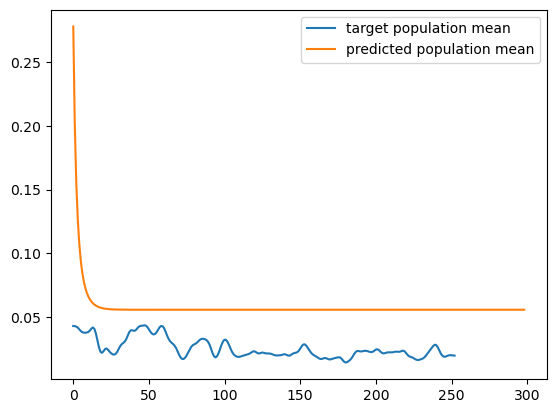

In [45]:
mean_target_t = Y_trial.mean(dim=1).detach().cpu().numpy()
mean_pred_t = yhat.mean(dim=1).detach().cpu().numpy()

plt.figure()
plt.plot(mean_target_t, label="target population mean")
plt.plot(mean_pred_t, label="predicted population mean")
plt.legend()
plt.show()

below are previous loading functions

In [46]:
import argparse
import encoding_GLM as glm #1 import GLM package
import glm_wrapper_functions_cluster as glm_wrapper #2 import wrapper functions that run glm
import importlib
importlib.reload(glm_wrapper)
import os
import pickle
from scipy import stats
import numpy as np


def run_glm_model_poss_updated(cellid,mouse,date,model_type,model_name):

    #1) specify model parameters 
    activation, loss_type, regularization, l1_ratio = 'exp', 'poisson', 'elastic_net', .95 #poisson or binomial
    #activation, loss_type, regularization, l1_ratio = 'sigmoid', 'binominal', 'elastic_net', .95 

    #2) make cel number into double and allow access to code
    cel = int(cellid)

    #3) get train and test directories

    # current directories
    # data_directory = "/ihome/crunyan/cdb66/Data" #SLURM ALREADY CD's to the directory
    # save_directory = "/ihome/crunyan/cdb66/Data"

    data_directory = os.path.join('/ix/crunyan/cdb66/Data',mouse,date,model_name) #SLURM ALREADY CD's to the directory
    save_directory = os.path.join('/ix/crunyan/cdb66/Data',mouse,date,model_name,'results_updated')

    # 4) check to see if we already run this particular neuron
    file_name = 'poss_model_' + model_type + '_data_cluster_' + cellid + '.pkl'
    file_path = os.path.join(save_directory, file_name)
    # if os.path.exists(file_path):
    #     print(f"File {file_path} already exists. Skipping model run.")
    #     return

    print(f"Running model for neuron {cellid}")
    num_folds = 10
    model_data_all = {}
    for fold_number in list(range(0,num_folds)): #can change this to fit however many folds you need 

        train_directory = data_directory + "/prepost trial cv 73 #{}".format(fold_number+1)
        test_directory = data_directory + "/prepost trial cv 73 #{}/test".format(fold_number+1)

        #print(f"Running model for neuron {cellid}")
        #[X_train, Y_train, X_test, Y_test, count_of_values, IDS_for_count_of_values] = glm_wrapper.glm_wrapper_functions_cluster.get_coupling_data_from_each_CV_fold_rawdeconv(train_directory, test_directory, fold_number+1, cel, 1)
        #[X_train, Y_train, X_test, Y_test, count_of_values, IDS_for_count_of_values] = glm_wrapper.glm_wrapper_functions_cluster.get_data_from_each_CV_fold(train_directory, test_directory, fold_number+1)
        if model_type == "0": 
            [X_train, Y_train, X_test, Y_test, count_of_values, IDS_for_count_of_values] = glm_wrapper.glm_wrapper_functions_cluster.get_data_from_each_CV_fold_rawdeconv(train_directory, test_directory, fold_number+1, cel)
            #z score predictors
            X_test = safe_zscore(X_test) #stats.zscore(X_test, axis=0, nan_policy='omit') # 
            X_train = safe_zscore(X_train) #stats.zscore(X_train, axis=0, nan_policy='omit') 
        elif model_type == "1":
            print('model_type 1')
            [X_train, Y_train, X_test, Y_test, count_of_values, IDS_for_count_of_values] = glm_wrapper.glm_wrapper_functions_cluster.get_coupling_data_from_each_CV_fold_rawdeconv(train_directory, test_directory, fold_number+1, cel, 1)
            #z score predictors
            X_test = safe_zscore(X_test) #stats.zscore(X_test, axis=0, nan_policy='omit')  
            X_train = safe_zscore(X_train) # stats.zscore(X_train, axis=0, nan_policy='omit') 
        elif model_type == "2":
            print('model_type 2')
            elimination_type = 0 #get rid of first 3 coupling predictors (PYR)
            [X_train, Y_train, X_test, Y_test, count_of_values, IDS_for_count_of_values] = glm_wrapper.glm_wrapper_functions_cluster.get_coupling_data_from_each_CV_fold_rawdeconv(train_directory, test_directory, fold_number+1, cel, 1, elimination_option = elimination_type)
            #z score predictors
            X_test = safe_zscore(X_test) #stats.zscore(X_test, axis=0, nan_policy='omit') 
            X_train = safe_zscore(X_train) # stats.zscore(X_train, axis=0, nan_policy='omit') 
        elif model_type == "3":
            print('model_type 3')
            elimination_type = 1 #get rid of second 3 coupling predictors (SOM)
            [X_train, Y_train, X_test, Y_test, count_of_values, IDS_for_count_of_values] = glm_wrapper.glm_wrapper_functions_cluster.get_coupling_data_from_each_CV_fold_rawdeconv(train_directory, test_directory, fold_number+1, cel, 1,  elimination_option = elimination_type)
            #z score predictors
            X_test = safe_zscore(X_test) #stats.zscore(X_test, axis=0, nan_policy='omit') 
            X_train = safe_zscore(X_train) # stats.zscore(X_train, axis=0, nan_policy='omit') 
        elif model_type == "4":
            print('model_type 4')
            elimination_type = 2 #get rid of last 3 coupling predictors (PV)
            [X_train, Y_train, X_test, Y_test, count_of_values, IDS_for_count_of_values] = glm_wrapper.glm_wrapper_functions_cluster.get_coupling_data_from_each_CV_fold_rawdeconv(train_directory, test_directory, fold_number+1, cel, 1,  elimination_option = elimination_type)
            #z score predictors
            X_test = safe_zscore(X_test) #stats.zscore(X_test, axis=0, nan_policy='omit')  
            X_train = safe_zscore(X_train) # stats.zscore(X_train, axis=0, nan_policy='omit') 

        elif model_type == "5":
            print('model_type 5')
            [X_train, Y_train, X_test, Y_test, count_of_values, IDS_for_count_of_values] = glm_wrapper.glm_wrapper_functions_cluster.get_coupling_data_from_each_CV_fold_rawdeconv_all_neurons(train_directory, test_directory, fold_number+1, cel, 1)
            #z score predictors
            X_test = safe_zscore(X_test) #stats.zscore(X_test, axis=0, nan_policy='omit')  
            X_train = safe_zscore(X_train) # stats.zscore(X_train, axis=0, nan_policy='omit') 

        #train model on GPU!
        model_trained = glm_wrapper.glm_wrapper_functions_cluster.train_model_on_cv_fold_GPU(X_train, Y_train, count_of_values, activation, loss_type, regularization, l1_ratio) 
        model_trained.select_model(X_test, Y_test, min_lambda = 0.0, make_fig = False)
        frac_dev_expl, dev_model, dev_null, dev_expl = model_trained.evaluate(X_test, Y_test, make_fig = False)
        B_weights = model_trained.selected_w
        intercept_weight = model_trained.selected_w0
        y_pred = model_trained.predict(X_test)
        selec_lambda = model_trained.selected_lambda


        # Extract additional hyperparameter information
        # loss_trace = model_trained.loss_trace
        # lambda_trace = model_trained.lambda_trace


        model_data = {
        'frac_dev_expl': frac_dev_expl,
        'dev_model': dev_model,
        'dev_null': dev_null, 
        'dev_expl': dev_expl, 
        'B_weights': B_weights,
        'intercept_weight': intercept_weight,
        'y_pred': y_pred,
        'selec_lambda': selec_lambda,
        # 'loss_trace': loss_trace,
        # 'lambda_trace': lambda_trace
        }

        ##below saves each cell in each fold- I will change to save just once when the entire fold is done running?
        # os.chdir(train_directory)

        # with open('model_data_cluster_' + cellid + '.pkl', 'wb') as file:
        #     pickle.dump(model_data, file) #add cell number to know that it was fit
        model_data_all[fold_number] = model_data

    os.makedirs(save_directory, exist_ok=True)
    os.chdir(save_directory)
    with open('poss_model_'+model_type+ '_data_cluster_' + cellid + '.pkl', 'wb') as file:
        pickle.dump(model_data_all, file) #add cell number to know that it was fit

    return model_data


ModuleNotFoundError: No module named 'encoding_GLM'